## Window Analyzer - NOT IMPORTANT ANYMORE

Initialized analyzer with 627 windows of length 10
🔋 EV TIME SERIES WINDOW ANALYSIS REPORT
BASIC WINDOW STATISTICS
Total number of events across all windows: 6263
Number of windows: 627
Sequence length per window: 10

Feature Statistics (across all windows):
----------------------------------------
duration_minutes:
  Mean: 92.67
  Std: 116.98
  Min: 16.05
  Max: 1011.80

km_driven:
  Mean: 24.50
  Std: 28.62
  Min: 0.00
  Max: 187.91

charge:
  Mean: -0.15
  Std: 11.47
  Min: -34.12
  Max: 36.64

WINDOW-LEVEL ANALYSIS
Window-level Summary Statistics:
----------------------------------------
        window_id  total_charge  net_charge  total_duration    total_km  \
count  627.000000    627.000000  627.000000      627.000000  627.000000   
mean   313.000000     -1.524764   -1.524764      925.684962  244.766669   
std    181.143589     20.319239   20.319239      424.791978   71.914521   
min      0.000000    -29.873458  -29.873458      201.162168   17.952573   
25%    156.500000    -17.7

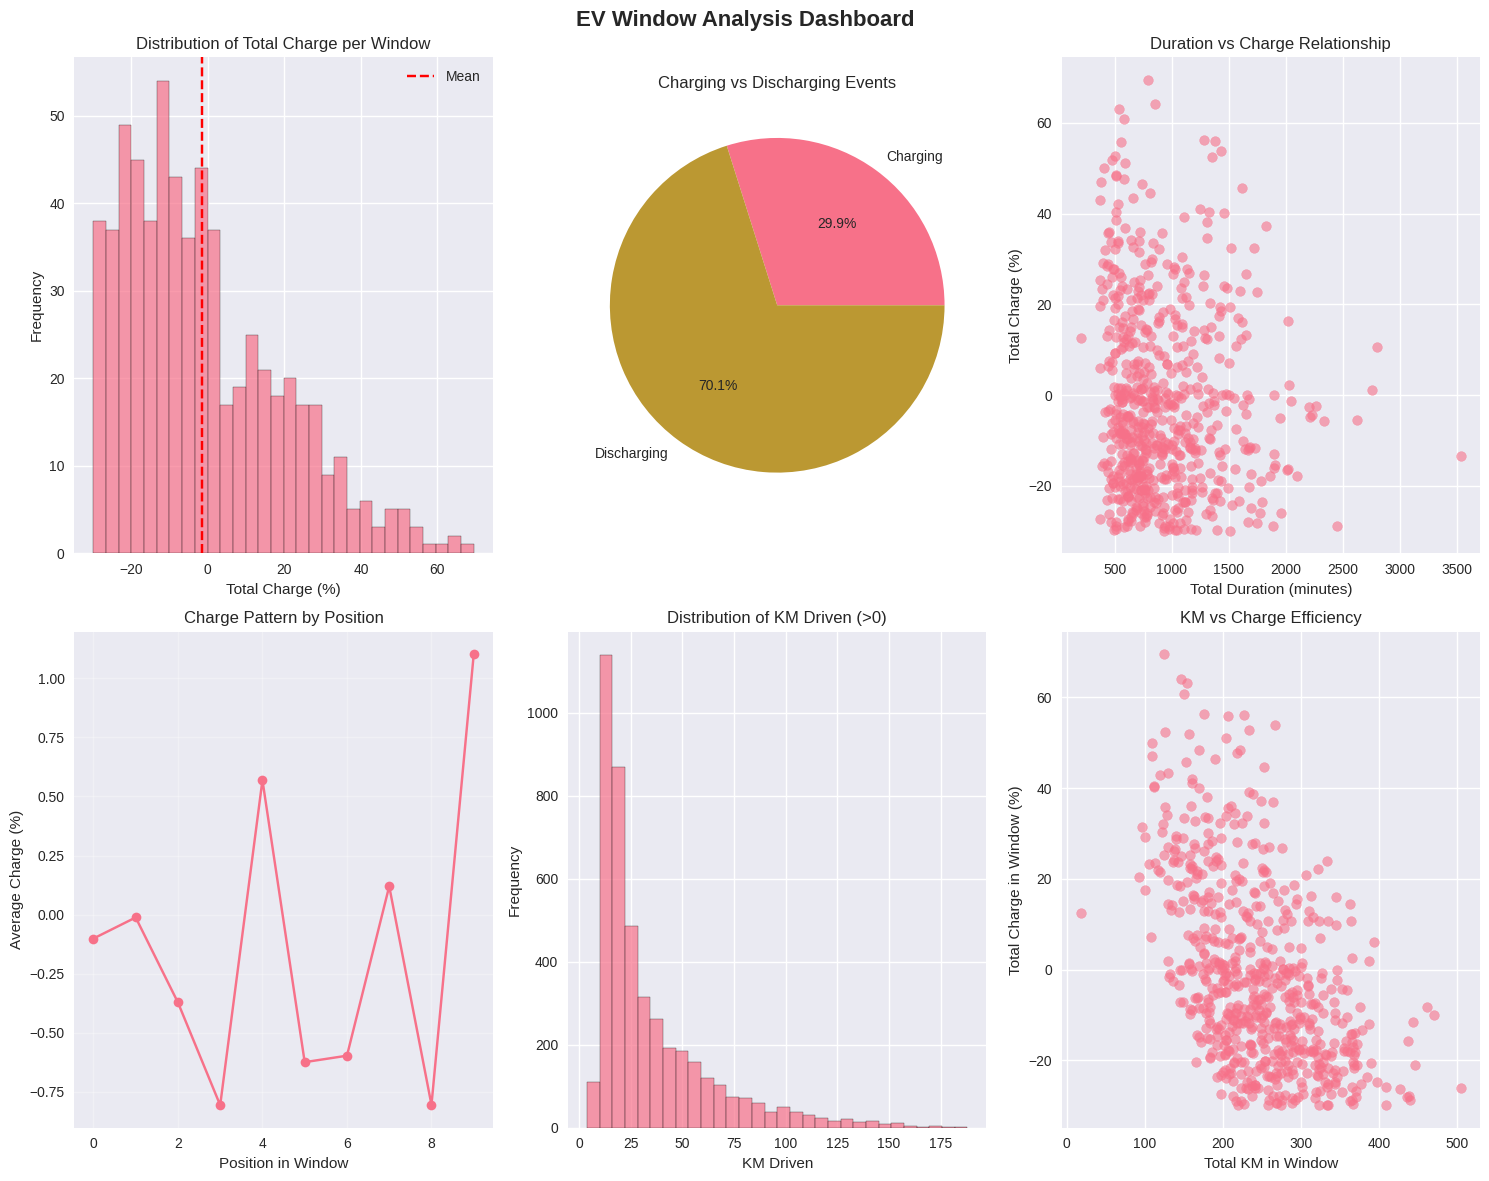

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EVWindowAnalyzer:
    """
    Comprehensive analyzer for EV time series windows
    """
    
    def __init__(self, windows_data, seq_len):
        """
        Initialize analyzer with windowed data
        
        Parameters:
        windows_data: array-like, shape (N_windows, seq_len, n_features)
                     or list of DataFrames
        seq_len: int, sequence length of each window
        """
        self.seq_len = seq_len
        self.feature_names = ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        
        # Convert to consistent format
        if isinstance(windows_data, list):
            self.windows = windows_data
            self.n_windows = len(windows_data)
        else:
            # Assume numpy array format
            self.windows = [pd.DataFrame(windows_data[i], columns=self.feature_names) 
                           for i in range(windows_data.shape[0])]
            self.n_windows = windows_data.shape[0]
        
        print(f"Initialized analyzer with {self.n_windows} windows of length {self.seq_len}")
        
    def basic_statistics(self):
        """Generate basic statistics about all windows"""
        print("="*60)
        print("BASIC WINDOW STATISTICS")
        print("="*60)
        
        # Aggregate all windows into one dataframe for global stats
        all_data = pd.concat(self.windows, ignore_index=True)
        
        print(f"Total number of events across all windows: {len(all_data)}")
        print(f"Number of windows: {self.n_windows}")
        print(f"Sequence length per window: {self.seq_len}")
        
        # Basic feature statistics
        print("\nFeature Statistics (across all windows):")
        print("-" * 40)
        for col in ['duration_minutes', 'km_driven', 'charge']:
            if col in all_data.columns:
                print(f"{col}:")
                print(f"  Mean: {all_data[col].mean():.2f}")
                print(f"  Std: {all_data[col].std():.2f}")
                print(f"  Min: {all_data[col].min():.2f}")
                print(f"  Max: {all_data[col].max():.2f}")
                print()
        
        return all_data
    
    def window_level_analysis(self):
        """Analyze characteristics at the window level"""
        print("="*60)
        print("WINDOW-LEVEL ANALYSIS")
        print("="*60)
        
        window_stats = []
        
        for i, window in enumerate(self.windows):
            stats_dict = {
                'window_id': i,
                'total_charge': window['charge'].sum(),
                'net_charge': window['charge'].sum(),  # same as total for now
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'n_charging_events': (window['charge'] > 0).sum(),
                'n_discharging_events': (window['charge'] < 0).sum(),
                'max_single_charge': window['charge'].max(),
                'min_single_charge': window['charge'].min(),
                'charging_efficiency': window[window['charge'] > 0]['charge'].sum() if (window['charge'] > 0).any() else 0,
                'discharging_total': abs(window[window['charge'] < 0]['charge'].sum()) if (window['charge'] < 0).any() else 0,
                'avg_event_duration': window['duration_minutes'].mean(),
                'longest_event': window['duration_minutes'].max(),
                'shortest_event': window['duration_minutes'].min()
            }
            
            # Event type analysis (if categorical)
            if 'event' in window.columns:
                event_counts = window['event'].value_counts()
                for event_type in event_counts.index:
                    stats_dict[f'n_{event_type}_events'] = event_counts[event_type]
            
            # Charge mode analysis (if categorical)
            if 'charge_mode' in window.columns:
                mode_counts = window['charge_mode'].value_counts()
                stats_dict['most_common_charge_mode'] = mode_counts.index[0] if len(mode_counts) > 0 else 'N/A'
                stats_dict['n_unique_charge_modes'] = len(mode_counts)
            
            window_stats.append(stats_dict)
        
        self.window_stats_df = pd.DataFrame(window_stats)
        
        # Display summary statistics
        print("Window-level Summary Statistics:")
        print("-" * 40)
        numeric_cols = self.window_stats_df.select_dtypes(include=[np.number]).columns
        print(self.window_stats_df[numeric_cols].describe())
        
        return self.window_stats_df
    
    def charge_analysis(self):
        """Deep dive into charging patterns"""
        print("="*60)
        print("CHARGING PATTERN ANALYSIS")
        print("="*60)
        
        # Charging vs Discharging analysis
        total_charging = sum(window[window['charge'] > 0]['charge'].sum() for window in self.windows)
        total_discharging = sum(abs(window[window['charge'] < 0]['charge'].sum()) for window in self.windows)
        
        print(f"Total charging across all windows: {total_charging:.2f}%")
        print(f"Total discharging across all windows: {total_discharging:.2f}%")
        print(f"Net battery charge: {total_charging - total_discharging:.2f}%")
        print(f"Charge/Discharge ratio: {total_charging/total_discharging:.2f}" if total_discharging > 0 else "Infinite (no discharging)")
        
        # Window charge distribution
        charge_dist = self.window_stats_df['total_charge']
        print(f"\nWindow Total Charge Distribution:")
        print(f"  Mean window charge: {charge_dist.mean():.2f}%")
        print(f"  Std window charge: {charge_dist.std():.2f}%")
        print(f"  Windows with net positive charge: {(charge_dist > 0).sum()}")
        print(f"  Windows with net negative charge: {(charge_dist < 0).sum()}")
        print(f"  Windows with net zero charge: {(charge_dist == 0).sum()}")
        
        return {
            'total_charging': total_charging,
            'total_discharging': total_discharging,
            'net_charge': total_charging - total_discharging
        }
    
    def temporal_patterns(self):
        """Analyze temporal patterns within windows"""
        print("="*60)
        print("TEMPORAL PATTERN ANALYSIS")
        print("="*60)
        
        # Analyze position-based patterns (early vs late in window)
        position_stats = []
        
        for pos in range(self.seq_len):
            pos_data = [window.iloc[pos] for window in self.windows if len(window) > pos]
            
            if pos_data:
                pos_df = pd.DataFrame(pos_data)
                position_stats.append({
                    'position': pos,
                    'avg_charge': pos_df['charge'].mean(),
                    'avg_duration': pos_df['duration_minutes'].mean(),
                    'avg_km': pos_df['km_driven'].mean(),
                    'charge_std': pos_df['charge'].std()
                })
        
        self.position_stats = pd.DataFrame(position_stats)
        
        print("Average patterns by position in window:")
        print(self.position_stats.round(2))
        
        # Find most/least active positions
        most_charge_pos = self.position_stats.loc[self.position_stats['avg_charge'].idxmax(), 'position']
        least_charge_pos = self.position_stats.loc[self.position_stats['avg_charge'].idxmin(), 'position']
        
        print(f"\nMost charging activity at position: {most_charge_pos}")
        print(f"Least charging activity at position: {least_charge_pos}")
        
        return self.position_stats
    
    def event_analysis(self):
        """Analyze event types and patterns"""
        print("="*60)
        print("EVENT TYPE ANALYSIS")
        print("="*60)
        
        # Aggregate all events
        all_events = pd.concat(self.windows, ignore_index=True)
        
        # Event type distribution
        if 'event' in all_events.columns:
            event_dist = all_events['event'].value_counts()
            print("Event type distribution:")
            for event_type, count in event_dist.items():
                pct = (count / len(all_events)) * 100
                print(f"  {event_type}: {count} ({pct:.1f}%)")
        
        # Charge mode distribution
        if 'charge_mode' in all_events.columns:
            mode_dist = all_events['charge_mode'].value_counts()
            print(f"\nCharge mode distribution:")
            for mode, count in mode_dist.items():
                pct = (count / len(all_events)) * 100
                print(f"  {mode}: {count} ({pct:.1f}%)")
        
        # Event characteristics by type
        if 'event' in all_events.columns:
            print(f"\nEvent characteristics by type:")
            event_chars = all_events.groupby('event')[['duration_minutes', 'km_driven', 'charge']].agg(['mean', 'std', 'count'])
            print(event_chars.round(2))
        
        return all_events
    
    def visualize_patterns(self, figsize=(15, 12)):
        """Create comprehensive visualizations"""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('EV Window Analysis Dashboard', fontsize=16, fontweight='bold')
        
        # 1. Window charge distribution
        axes[0,0].hist(self.window_stats_df['total_charge'], bins=30, alpha=0.7, edgecolor='black')
        axes[0,0].set_title('Distribution of Total Charge per Window')
        axes[0,0].set_xlabel('Total Charge (%)')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].axvline(self.window_stats_df['total_charge'].mean(), color='red', linestyle='--', label='Mean')
        axes[0,0].legend()
        
        # 2. Charging vs Discharging events
        charge_pos = self.window_stats_df['n_charging_events'].sum()
        charge_neg = self.window_stats_df['n_discharging_events'].sum()
        axes[0,1].pie([charge_pos, charge_neg], labels=['Charging', 'Discharging'], autopct='%1.1f%%')
        axes[0,1].set_title('Charging vs Discharging Events')
        
        # 3. Total duration vs total charge scatter
        axes[0,2].scatter(self.window_stats_df['total_duration'], self.window_stats_df['total_charge'], alpha=0.6)
        axes[0,2].set_xlabel('Total Duration (minutes)')
        axes[0,2].set_ylabel('Total Charge (%)')
        axes[0,2].set_title('Duration vs Charge Relationship')
        
        # 4. Temporal patterns (position-based)
        if hasattr(self, 'position_stats'):
            axes[1,0].plot(self.position_stats['position'], self.position_stats['avg_charge'], marker='o')
            axes[1,0].set_xlabel('Position in Window')
            axes[1,0].set_ylabel('Average Charge (%)')
            axes[1,0].set_title('Charge Pattern by Position')
            axes[1,0].grid(True, alpha=0.3)
        
        # 5. KM driven distribution
        all_km = pd.concat(self.windows)['km_driven']
        axes[1,1].hist(all_km[all_km > 0], bins=30, alpha=0.7, edgecolor='black')
        axes[1,1].set_xlabel('KM Driven')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].set_title('Distribution of KM Driven (>0)')
        
        # 6. Charge efficiency scatter
        axes[1,2].scatter(self.window_stats_df['total_km'], self.window_stats_df['total_charge'], alpha=0.6)
        axes[1,2].set_xlabel('Total KM in Window')
        axes[1,2].set_ylabel('Total Charge in Window (%)')
        axes[1,2].set_title('KM vs Charge Efficiency')
        
        plt.tight_layout()
        plt.show()
    
    def data_quality_check(self):
        """Check for data quality issues"""
        print("="*60)
        print("DATA QUALITY CHECK")
        print("="*60)
        
        issues = []
        
        # Check for missing values
        for i, window in enumerate(self.windows):
            missing = window.isnull().sum()
            if missing.any():
                issues.append(f"Window {i}: Missing values - {missing.to_dict()}")
        
        # Check for impossible values
        all_data = pd.concat(self.windows, ignore_index=True)
        
        if (all_data['charge'] > 100).any():
            issues.append("Found charge values > 100%")
        if (all_data['charge'] < -100).any():
            issues.append("Found charge values < -100%")
        if (all_data['duration_minutes'] < 0).any():
            issues.append("Found negative duration values")
        if (all_data['km_driven'] < 0).any():
            issues.append("Found negative km_driven values")
        
        # Check window length consistency
        lengths = [len(w) for w in self.windows]
        if not all(l == self.seq_len for l in lengths):
            issues.append(f"Inconsistent window lengths: {set(lengths)}")
        
        if issues:
            print("ISSUES FOUND:")
            for issue in issues:
                print(f"⚠️  {issue}")
        else:
            print("✅ No data quality issues detected!")
        
        return issues
    
    def generate_report(self):
        """Generate a comprehensive analysis report"""
        print("🔋 EV TIME SERIES WINDOW ANALYSIS REPORT")
        print("="*70)
        
        # Run all analyses
        basic_data = self.basic_statistics()
        window_stats = self.window_level_analysis()
        charge_analysis = self.charge_analysis()
        temporal_patterns = self.temporal_patterns()
        event_data = self.event_analysis()
        quality_issues = self.data_quality_check()
        
        # Generate visualizations
        self.visualize_patterns()
        
        return {
            'basic_stats': basic_data,
            'window_stats': window_stats,
            'charge_summary': charge_analysis,
            'temporal_patterns': temporal_patterns,
            'event_analysis': event_data,
            'quality_issues': quality_issues
        }

#USAGE
import pandas as pd

############################
data_to_load = 'generated'##
############################



if data_to_load == 'generated':
    # Load the CSV
    df = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/valid_windows.csv')
    
elif data_to_load == 'original':

    df = pd.read_csv('./datasets/EV_data.csv')
    df['charge'] = df['end_soc'] - df['soc']
    df['km_driven'] = df['end_odo'] - df['odo']
    # Convert timestamps to datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

    # Compute event duration in minutes
    df['duration_minutes'] = (df['end_time'] - df['timestamp']).dt.total_seconds() / 60
    
# Define window size
seq_len = 10   
# Split into a list of DataFrames
dfs = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]

# Keep only those where sum of 'charge' is between a reasonable range
dfs = [d for d in dfs if -30 <= d['charge'].sum() <= 75]

analyzer = EVWindowAnalyzer(dfs, seq_len=seq_len)
results = analyzer.generate_report()


## Timeline reconstruction

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import List, Tuple, Dict, Optional, Set
import heapq
from dataclasses import dataclass
import networkx as nx
import seaborn as sns

import random
import numpy as np
import math
import time
from typing import List, Optional, Tuple, Dict
import matplotlib.pyplot as plt

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Advanced algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(20, 80),
                 min_soc: float = 0.0,
                 max_soc: float = 100.0):
        """
        Initialize the reconstructor
        
        Parameters:
        windows: List of window DataFrames with columns ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        initial_battery_range: Tuple of (min, max) reasonable starting battery levels
        """
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]

        # Custom SoC bounds
        self.min_soc = min_soc
        self.max_soc = max_soc
        
        print(f"🔋 Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        # Precompute window statistics for optimization
        self.precompute_window_stats()

        
    def precompute_window_stats(self):
        """Precompute statistics for each window to speed up algorithms"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,  # Will compute below
                'max_intermediate_charge': 0,  # Will compute below
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            # Calculate intermediate battery requirements
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)

        
    def window_ends_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window ends with a charge, else None"""
        w = self.windows[window_id]
        last_event = w.iloc[-1]
        if last_event['event'] == 'charge':
            return str(last_event['charge_mode'])
        return None
    
    def window_starts_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window starts with a charge, else None"""
        w = self.windows[window_id]
        first_event = w.iloc[0]
        if first_event['event'] == 'charge':
            return str(first_event['charge_mode'])
        return None
    
    def algorithm_genetic(self, start_battery: float, 
                         population_size: int = 200,
                         generations: int = 1000,
                         mutation_rate: float = 0.15,
                         crossover_rate: float = 0.85,
                         elite_ratio: float = 0.1,
                         tournament_size: int = 7,
                         adaptive_params: bool = True) -> Optional[List[int]]:
        """
        Genetic Algorithm for EV Timeline Reconstruction
        
        Features:
        - Multiple crossover operators (Order, PMX, Cycle)
        - Adaptive mutation rates
        - Multiple mutation operators
        - Tournament and rank selection
        - Elitism with diversity preservation
        - Local search improvements
        - Constraint-aware fitness function
        """
        print("🧬 Running Genetic Algorithm...")
        
        def create_individual() -> List[int]:
            """Create a random individual with smart initialization strategies"""
            strategy = random.choice(['random', 'greedy_init', 'cluster_init'])
            
            if strategy == 'random':
                individual = list(range(self.n_windows))
                random.shuffle(individual)
                return individual
            
            elif strategy == 'greedy_init':
                # Greedy initialization: build sequence by always choosing feasible next window
                individual = []
                remaining = set(range(self.n_windows))
                current_battery = start_battery
                
                # Start with a random feasible window
                feasible_starts = []
                for w in remaining:
                    stats = self.window_stats[w]
                    if (current_battery + stats['min_intermediate_charge'] >= 0 and 
                        current_battery + stats['max_intermediate_charge'] <= 100):
                        feasible_starts.append(w)
                
                if feasible_starts:
                    current = random.choice(feasible_starts)
                    individual.append(current)
                    remaining.remove(current)
                    current_battery += self.window_stats[current]['net_charge']
                
                # Greedily add remaining windows
                while remaining:
                    best_candidates = []
                    for w in remaining:
                        stats = self.window_stats[w]
                        if (current_battery + stats['min_intermediate_charge'] >= 0 and 
                            current_battery + stats['max_intermediate_charge'] <= 100):
                            end_battery = current_battery + stats['net_charge']
                            score = -abs(end_battery - 50)  # Prefer staying near 50%
                            best_candidates.append((score, w))
                    
                    if best_candidates:
                        best_candidates.sort(reverse=True)
                        # Choose from top candidates with some randomness
                        top_n = min(3, len(best_candidates))
                        current = best_candidates[random.randint(0, top_n-1)][1]
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                    else:
                        # Fallback: add any remaining window
                        current = random.choice(list(remaining))
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                
                return individual
            
            else:  # cluster_init
                # Cluster similar windows and mix clusters
                individual = list(range(self.n_windows))
                # Simple clustering by net charge
                positive_windows = [i for i in individual if self.window_stats[i]['net_charge'] > 0]
                negative_windows = [i for i in individual if self.window_stats[i]['net_charge'] < 0]
                neutral_windows = [i for i in individual if self.window_stats[i]['net_charge'] == 0]
                
                random.shuffle(positive_windows)
                random.shuffle(negative_windows)
                random.shuffle(neutral_windows)
                
                # Interleave clusters
                result = []
                max_len = max(len(positive_windows), len(negative_windows), len(neutral_windows))
                for i in range(max_len):
                    if i < len(positive_windows):
                        result.append(positive_windows[i])
                    if i < len(negative_windows):
                        result.append(negative_windows[i])
                    if i < len(neutral_windows):
                        result.append(neutral_windows[i])
                
                return result
        
        def fitness(individual: List[int]) -> float:
            """
            Advanced fitness function combining multiple objectives
            Returns higher values for better solutions
            """
            battery = start_battery
            penalty = 0
            battery_trace = [battery]
            
            # Battery constraint violations (heavy penalty)
            for window_id in individual:
                stats = self.window_stats[window_id]
                
                # Check intermediate constraints
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < 0:
                    penalty += (0 - min_battery) * 2000  # Very heavy penalty
                if max_battery > 100:
                    penalty += (max_battery - 100) * 2000  # Very heavy penalty
                
                battery += stats['net_charge']
                battery_trace.append(battery)
                
                # Final battery constraint
                if battery < 0:
                    penalty += abs(battery) * 1500
                if battery > 100:
                    penalty += (battery - 100) * 1500
            
            # Battery optimization objectives (smaller penalties)
            battery_variance = np.var(battery_trace)
            mean_distance_from_optimal = np.mean([abs(b - 50) for b in battery_trace])
            
            penalty += battery_variance * 0.5  # Prefer stable battery levels
            penalty += mean_distance_from_optimal * 2  # Prefer levels near 50%
            
            # Bonus for good final battery level
            final_battery = battery_trace[-1]
            if 20 <= final_battery <= 80:
                penalty -= 50
            
            # Bonus for avoiding extreme swings
            max_swing = max(battery_trace) - min(battery_trace)
            if max_swing < 60:
                penalty -= 20
            
            return -penalty  # Convert to fitness (higher is better)
        
        def tournament_selection(population: List[List[int]], k: int = None) -> List[int]:
            """Tournament selection with adaptive tournament size"""
            if k is None:
                k = tournament_size
            tournament = random.sample(population, min(k, len(population)))
            return max(tournament, key=fitness)
        
        def rank_selection(population: List[List[int]]) -> List[int]:
            """Rank-based selection"""
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            # Assign ranks (higher rank = better fitness)
            ranks = list(range(len(population_with_fitness), 0, -1))
            total_rank = sum(ranks)
            
            # Roulette wheel selection based on ranks
            pick = random.uniform(0, total_rank)
            current = 0
            for i, rank in enumerate(ranks):
                current += rank
                if current >= pick:
                    return population_with_fitness[i][0]
            
            return population_with_fitness[0][0]  # Fallback
        
        def order_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Order crossover (OX) - preserves relative order"""
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = [None] * n
            child2 = [None] * n
            
            # Copy middle sections
            child1[start:end] = parent1[start:end]
            child2[start:end] = parent2[start:end]
            
            # Fill remaining positions
            def fill_child(child, other_parent):
                remaining = [x for x in other_parent if x not in child]
                remaining_iter = iter(remaining)
                for i in range(n):
                    if child[i] is None:
                        child[i] = next(remaining_iter)
            
            fill_child(child1, parent2)
            fill_child(child2, parent1)
            
            return child1, child2
        
        def pmx_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Partially Mapped Crossover (PMX)"""
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = parent1.copy()
            child2 = parent2.copy()
            
            # Create mapping between crossover segments
            mapping1 = {}
            mapping2 = {}
            
            for i in range(start, end):
                # Swap elements in crossover region
                val1, val2 = child1[i], child2[i]
                child1[i], child2[i] = val2, val1
                mapping1[val2] = val1
                mapping2[val1] = val2
            
            # Fix conflicts outside crossover region
            def fix_conflicts(child, mapping):
                for i in list(range(0, start)) + list(range(end, n)):
                    while child[i] in mapping:
                        child[i] = mapping[child[i]]
            
            fix_conflicts(child1, mapping1)
            fix_conflicts(child2, mapping2)
            
            return child1, child2
        
        def cycle_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            """Cycle crossover (CX)"""
            n = len(parent1)
            child1 = [None] * n
            child2 = [None] * n
            
            visited = [False] * n
            
            for start in range(n):
                if visited[start]:
                    continue
                
                # Determine which parent to start the cycle from
                use_parent1 = (sum(visited) // n) % 2 == 0
                
                # Follow the cycle
                current = start
                while not visited[current]:
                    visited[current] = True
                    if use_parent1:
                        child1[current] = parent1[current]
                        child2[current] = parent2[current]
                    else:
                        child1[current] = parent2[current]
                        child2[current] = parent1[current]
                    
                    # Find next position in cycle
                    target_val = parent2[current] if use_parent1 else parent1[current]
                    current = parent1.index(target_val)
            
            return child1, child2
        
        def mutate(individual: List[int], rate: float) -> List[int]:
            """Advanced mutation with multiple operators"""
            if random.random() > rate:
                return individual
            
            mutated = individual.copy()
            mutation_type = random.choice(['swap', 'insert', 'inversion', 'scramble'])
            
            if mutation_type == 'swap':
                # Simple swap mutation
                i, j = random.sample(range(len(mutated)), 2)
                mutated[i], mutated[j] = mutated[j], mutated[i]
            
            elif mutation_type == 'insert':
                # Insert mutation: remove element and insert elsewhere
                i = random.randint(0, len(mutated) - 1)
                element = mutated.pop(i)
                j = random.randint(0, len(mutated))
                mutated.insert(j, element)
            
            elif mutation_type == 'inversion':
                # Inversion mutation: reverse a segment
                i, j = sorted(random.sample(range(len(mutated)), 2))
                mutated[i:j+1] = reversed(mutated[i:j+1])
            
            elif mutation_type == 'scramble':
                # Scramble mutation: shuffle a segment
                i, j = sorted(random.sample(range(len(mutated)), 2))
                segment = mutated[i:j+1]
                random.shuffle(segment)
                mutated[i:j+1] = segment
            
            return mutated
        
        def local_search(individual: List[int], max_improvements: int = 5) -> List[int]:
            """Local search to improve solution"""
            current = individual.copy()
            current_fitness = fitness(current)
            improvements = 0
            
            for _ in range(20):  # Limited iterations
                if improvements >= max_improvements:
                    break
                
                # Try 2-opt style improvements
                best_neighbor = None
                best_fitness = current_fitness
                
                for i in range(len(current)):
                    for j in range(i + 1, len(current)):
                        # Try swap
                        neighbor = current.copy()
                        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                        
                        neighbor_fitness = fitness(neighbor)
                        if neighbor_fitness > best_fitness:
                            best_neighbor = neighbor
                            best_fitness = neighbor_fitness
                
                if best_neighbor is not None:
                    current = best_neighbor
                    current_fitness = best_fitness
                    improvements += 1
                else:
                    break
            
            return current
        
        # Initialize population
        population = [create_individual() for _ in range(population_size)]
        
        best_individual = None
        best_fitness = float('-inf')
        stagnation_counter = 0
        fitness_history = []
        
        # Adaptive parameters
        current_mutation_rate = mutation_rate
        current_tournament_size = tournament_size
        
        for generation in range(generations):
            # Evaluate population
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            # Track best solution
            current_best_fitness = population_with_fitness[0][1]
            fitness_history.append(current_best_fitness)
            
            if current_best_fitness > best_fitness:
                best_individual = population_with_fitness[0][0].copy()
                best_fitness = current_best_fitness
                stagnation_counter = 0
            else:
                stagnation_counter += 1
            
            # Adaptive parameters
            if adaptive_params:
                if stagnation_counter > 20:
                    current_mutation_rate = min(0.3, current_mutation_rate * 1.1)
                    current_tournament_size = max(3, current_tournament_size - 1)
                elif stagnation_counter < 5:
                    current_mutation_rate = max(0.05, current_mutation_rate * 0.95)
                    current_tournament_size = min(10, current_tournament_size + 1)
            
            # Early stopping
            if stagnation_counter > 100:
                print(f"  Early stopping at generation {generation}")
                break
            
            if generation % 50 == 0:
                avg_fitness = np.mean([f for _, f in population_with_fitness])
                print(f"  Generation {generation}: Best = {best_fitness:.2f}, Avg = {avg_fitness:.2f}, "
                      f"Mutation = {current_mutation_rate:.3f}")
            
            # Create new population
            new_population = []
            elite_size = int(population_size * elite_ratio)
            
            # Elitism with diversity
            elite_individuals = [ind for ind, _ in population_with_fitness[:elite_size]]
            new_population.extend(elite_individuals)
            
            # Apply local search to some elite individuals
            if generation % 10 == 0:
                for i in range(min(3, len(elite_individuals))):
                    elite_individuals[i] = local_search(elite_individuals[i])
            
            # Generate offspring
            while len(new_population) < population_size:
                if random.random() < crossover_rate:
                    # Select parents
                    if random.random() < 0.7:
                        parent1 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                        parent2 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                    else:
                        parent1 = rank_selection([ind for ind, _ in population_with_fitness])
                        parent2 = rank_selection([ind for ind, _ in population_with_fitness])
                    
                    # Choose crossover operator
                    crossover_op = random.choice([order_crossover, pmx_crossover, cycle_crossover])
                    child1, child2 = crossover_op(parent1, parent2)
                    
                    # Mutate offspring
                    child1 = mutate(child1, current_mutation_rate)
                    child2 = mutate(child2, current_mutation_rate)
                    
                    new_population.append(child1)
                    if len(new_population) < population_size:
                        new_population.append(child2)
                else:
                    # Direct mutation of selected individual
                    parent = tournament_selection([ind for ind, _ in population_with_fitness])
                    child = mutate(parent, current_mutation_rate * 2)  # Higher mutation for direct offspring
                    new_population.append(child)
            
            population = new_population[:population_size]
        
        print(f"  Final best fitness: {best_fitness:.2f}")
        return best_individual if best_fitness > float('-inf') else None
    

    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 20000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """
        Algorithm 2: Simulated Annealing with Battery Constraints
        """
        print("🔥 Running Algorithm 2: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness of a sequence (lower is better)"""
            battery = start_battery
            cost = 0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]

                # 🚫 Penalize consecutive same-mode charge windows
                if i > 0:
                    prev_id = sequence[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode == start_mode:
                        cost += 5000  # Heavy penalty
                
                # Check intermediate battery constraints
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    cost += (self.min_soc - min_battery) * 1000  # Heavy penalty
                if max_battery > self.max_soc:
                    cost += (max_battery - self.max_soc) * 1000  # Heavy penalty
                
                battery += stats['net_charge']
                
                # Prefer battery levels around 50%
                cost += abs(battery - 50) * 0.1
            
            return cost
        
        def get_neighbor(sequence: List[int]) -> List[int]:
            """Generate neighbor by swapping two random windows"""
            new_seq = sequence.copy()
            i, j = random.sample(range(len(new_seq)), 2)
            new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            return new_seq
        
        # Initialize with random sequence
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            # Generate neighbor
            neighbor = get_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            # Accept or reject
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / temp):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            # Cool down
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}")
        
        return best_sequence if best_cost < float('inf') else None
    
    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """
        Main method to reconstruct timeline using multiple algorithms
        
        Returns best solution found across all algorithms
        """
        print("🔄 Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)

        # Validate start_battery is within custom bounds
        if start_battery < self.min_soc or start_battery > self.max_soc:
            print(f"⚠️  Warning: start_battery ({start_battery}%) outside bounds [{self.min_soc}%, {self.max_soc}%]")
            start_battery = np.clip(start_battery, self.min_soc, self.max_soc)
            print(f"   Adjusted to: {start_battery}%")
        
        print(f"Starting battery level: {start_battery:.1f}%")
        
        solutions = {}
        
        # Try all algorithms 
        algorithms = [
            ("Simulated Annealing", self.algorithm_2_simulated_annealing)
        ]

        '''("Genetic Algorithm", self.algorithm_genetic)'''
        
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    # Validate solution
                    is_valid, final_battery, trace = self.validate_solution(solution, start_battery)
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'score': self.score_solution(solution, start_battery)
                        }
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%)")
                    else:
                        print(f"❌ {name}: Invalid solution")
                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                print(f"❌ {name}: Error - {e}")
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        # Find best solution
        best_name = min(solutions.keys(), key=lambda k: solutions[k]['score'])
        best_solution = solutions[best_name]
        
        print(f"\n🏆 Best solution: {best_name}")
        print(f"Sequence: {best_solution['sequence']}")
        print(f"Final battery: {best_solution['final_battery']:.1f}%")
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': start_battery
        }
    
    def validate_solution(self, sequence: List[int], start_battery: float) -> Tuple[bool, float, List[float]]:
        """Validate that a solution respects all battery constraints"""
        battery = start_battery
        trace = [battery]
        
        for window_id in sequence:
            window = self.windows[window_id]
            
            # Simulate execution of this window
            for _, event in window.iterrows():
                battery += event['charge']
                if battery < self.min_soc or battery > self.max_soc:
                    return False, battery, trace
                trace.append(battery)
        
        return True, battery, trace
    
    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, trace = self.validate_solution(sequence, start_battery)
        
        # Penalize extreme battery levels
        score = sum(abs(b - 50) for b in trace) / len(trace)
        
        # Bonus for reasonable final battery
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(15, 10)):
        """Visualize the reconstruction results"""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = best_sol['trace']
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # Compute statistics with numpy
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        # Print statistics
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        # 1. Battery level trajectory
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=100, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        
        # Clearer legend: top-right, with background box
        axes[0,0].legend(
            loc='upper right',
            frameon=True,
            facecolor='white',
            framealpha=0.9,
            edgecolor='black'
        )


       
        # 2. Window sequence net charges
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        bars = axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)
        
        
        # 3. Algorithm performance comparison
        if 'all_solutions' in result and len(result['all_solutions']) >= 1:
            algo_names = list(result['all_solutions'].keys())
            scores = [result['all_solutions'][name]['score'] for name in algo_names]
            colors_algo = ['gold' if name == 'Genetic Algorithm' else 'skyblue' for name in algo_names]
            
            bars = axes[1,0].bar(range(len(algo_names)), scores, color=colors_algo, alpha=0.8)
            axes[1,0].set_xlabel('Algorithm')
            axes[1,0].set_ylabel('Score (lower is better)')
            axes[1,0].set_title('Algorithm Performance Comparison')
            axes[1,0].set_xticks(range(len(algo_names)))
            axes[1,0].set_xticklabels([name.replace(' ', '\n') for name in algo_names], fontsize=10)
            axes[1,0].grid(True, alpha=0.3)
            
            # Highlight best algorithm
            best_idx = scores.index(min(scores))
            bars[best_idx].set_edgecolor('red')
            bars[best_idx].set_linewidth(3)
        
        # 4. Battery statistics distribution
        axes[1,1].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,1].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,1].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        #axes[1,1].axvspan(20, 80, alpha=0.1, color='green', label='Safe Zone')
        axes[1,1].set_xlabel('Battery Level (%)')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Battery Level Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_xlim([0, 100])
        
        plt.tight_layout()
        plt.show()
        
        # Additional analysis
        print(f"\nSequence Analysis:")
        print(f"  Window sequence: {sequence}")
        print(f"  Sequence length: {len(sequence)}")
        print(f"  Battery stability (low std is better): {std_soc:.2f}%")
        print(f"  Time in critical low battery (<10%): {sum(1 for b in trace if b < 10)/len(trace)*100:.1f}%")
        print(f"  Time in low battery (10-20%): {sum(1 for b in trace if 10 <= b < 20)/len(trace)*100:.1f}%")
        print(f"  Time in normal battery zone (20-80%): {sum(1 for b in trace if 20 <= b <= 80)/len(trace)*100:.1f}%")
        print(f"  Time in high zone (80-90%): {sum(1 for b in trace if 80 < b < 90)/len(trace)*100:.1f}%")
        print(f"  Time in very high zone (>90%): {sum(1 for b in trace if b >= 90)/len(trace)*100:.1f}%")
        
        # Window charge balance analysis
        positive_windows = sum(1 for w in window_charges if w > 0)
        negative_windows = sum(1 for w in window_charges if w < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net charge: {sum(window_charges):.1f}%")


# Demo execution
if __name__ == "__main__":
    
    # Load the CSV
    df = pd.read_csv('./selected_windows_balanced.csv')
    #df = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/valid_data_no_penalty.csv')
    
    # Define window size
    seq_len = 10
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(0, 1200, seq_len)]
    #dfs = [w for w in dfs if (w['charge'].sum() >= -50 and w['charge'].sum() <= 57)]

    
    # Initialize reconstructor
    reconstructor = EVTimelineReconstructor(
        dfs, 
        initial_battery_range=(0, 100),
        min_soc=6.0,   #  minimum SoC allowed
        max_soc=100.0  #  maximum SoC allowed
    )
    
    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=6.0)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)

🔋 Initializing timeline reconstructor with 80 windows
Window net charges: ['51.0%', '-15.9%', '-12.6%', '-22.2%', '-7.0%', '14.6%', '-4.1%', '-7.5%', '7.8%', '-9.1%', '-10.3%', '-25.6%', '-8.6%', '0.5%', '-24.7%', '-9.9%', '27.4%', '6.8%', '-28.1%', '68.5%', '-28.8%', '-26.5%', '64.3%', '2.5%', '-19.8%', '-22.0%', '14.1%', '20.0%', '7.8%', '-12.8%', '-11.9%', '64.2%', '7.4%', '-28.3%', '-14.6%', '-24.9%', '-10.7%', '-14.2%', '-0.3%', '-0.2%', '-8.5%', '-14.4%', '18.7%', '35.8%', '-9.1%', '7.0%', '-0.8%', '-17.1%', '-23.8%', '-23.3%', '36.2%', '17.0%', '2.8%', '-20.3%', '59.8%', '-19.5%', '4.5%', '-14.2%', '-26.4%', '-30.9%', '-21.0%', '-18.2%', '-31.7%', '-6.7%', '-23.3%', '17.3%', '14.4%', '9.1%', '-27.4%', '29.7%', '-30.7%', '-6.5%', '-26.0%', '29.8%', '47.6%', '-14.3%', '-4.7%', '-17.6%', '2.1%', '15.9%']
Total net charge across all windows: -131.91569694637582
🔄 Starting EV Timeline Reconstruction...
Starting battery level: 100.0%
🔥 Running Algorithm 2: Simulated Annealing...
  Ite

KeyboardInterrupt: 

## EXPERIMENT: AVOID WINDOWS THAT YIELD TO CONSECUTIVE CHARGES

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import List, Tuple, Dict, Optional, Set
import heapq
from dataclasses import dataclass

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Advanced algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(20, 80),
                 min_soc: float = 0.0,
                 max_soc: float = 100.0,
                 different_mode_penalty: float = 10000.0):
        """
        Initialize the reconstructor
        
        Parameters:
        windows: List of window DataFrames with columns ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        initial_battery_range: Tuple of (min, max) reasonable starting battery levels
        different_mode_penalty: Penalty for consecutive different-mode charges (default: 10000.0)
        """
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]

        # Custom SoC bounds
        self.min_soc = min_soc
        self.max_soc = max_soc
        
        # Penalty for different charge mode violations
        self.different_mode_penalty = different_mode_penalty
        
        print(f"🔋 Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        # Precompute window statistics for optimization
        self.precompute_window_stats()

        
    def precompute_window_stats(self):
        """Precompute statistics for each window to speed up algorithms"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,
                'max_intermediate_charge': 0,
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            # Calculate intermediate battery requirements
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)

        
    def window_ends_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window ends with a charge, else None"""
        w = self.windows[window_id]
        last_event = w.iloc[-1]
        if last_event['event'] == 'charge':
            return str(last_event['charge_mode'])
        return None
    
    def window_starts_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window starts with a charge, else None"""
        w = self.windows[window_id]
        first_event = w.iloc[0]
        if first_event['event'] == 'charge':
            return str(first_event['charge_mode'])
        return None
    
    def check_consecutive_different_mode_violation(self, sequence: List[int]) -> Tuple[bool, int]:
        """
        Check if sequence has consecutive DIFFERENT-mode charge violations
        Returns: (has_violation, number_of_violations)
        
        A violation occurs when a window ending with charge mode X is followed by
        a window starting with charge mode Y where X != Y
        """
        violations = 0
        for i in range(len(sequence) - 1):
            end_mode = self.window_ends_with_charge_mode(sequence[i])
            start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
            
            # Violation: both are charging events but with DIFFERENT modes
            if end_mode is not None and start_mode is not None and end_mode != start_mode:
                violations += 1
        
        return violations > 0, violations

    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 20000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """
        Simulated Annealing with Battery Constraints and Different-Mode Penalty
        """
        print("🔥 Running Algorithm 2: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness - WITH DIFFERENT-MODE PENALTY"""
            battery = start_battery
            cost = 0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]

                # 🚫 Penalize consecutive DIFFERENT-mode charge windows
                if i > 0:
                    prev_id = sequence[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    cost += (self.min_soc - min_battery) * 1000
                if max_battery > self.max_soc:
                    cost += (max_battery - self.max_soc) * 1000
                
                battery += stats['net_charge']
                cost += abs(battery - 50) * 0.1
            
            return cost

        
        def get_neighbor(sequence: List[int]) -> List[int]:
            """Generate neighbor - with mode-aware swapping"""
            neighbor_type = random.choice(['swap', 'insert', 'mode_aware_swap'])
            
            if neighbor_type == 'mode_aware_swap':
                new_seq = sequence.copy()
                has_violation, _ = self.check_consecutive_different_mode_violation(new_seq)
                
                if has_violation:
                    violation_positions = []
                    for i in range(len(new_seq) - 1):
                        end_mode = self.window_ends_with_charge_mode(new_seq[i])
                        start_mode = self.window_starts_with_charge_mode(new_seq[i + 1])
                        if end_mode is not None and start_mode is not None and end_mode != start_mode:
                            violation_positions.append(i)
                    
                    if violation_positions:
                        violation_pos = random.choice(violation_positions)
                        other_pos = random.choice([p for p in range(len(new_seq)) if p not in [violation_pos, violation_pos + 1]])
                        new_seq[violation_pos + 1], new_seq[other_pos] = new_seq[other_pos], new_seq[violation_pos + 1]
                        return new_seq
                
                i, j = random.sample(range(len(new_seq)), 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
                return new_seq
            
            elif neighbor_type == 'insert':
                new_seq = sequence.copy()
                i = random.randint(0, len(new_seq) - 1)
                element = new_seq.pop(i)
                j = random.randint(0, len(new_seq))
                new_seq.insert(j, element)
                return new_seq
            
            else:  # swap
                new_seq = sequence.copy()
                i, j = random.sample(range(len(new_seq)), 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
                return new_seq
        
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            neighbor = get_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / temp):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"  Final best cost: {best_cost:.2f}")
        
        if best_sequence:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_sequence)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_sequence if best_cost < float('inf') else None
    
    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """
        Main method to reconstruct timeline using multiple algorithms
        
        Returns best solution found across all algorithms
        """
        print("🔄 Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)

        # Validate start_battery is within custom bounds
        if start_battery < self.min_soc or start_battery > self.max_soc:
            print(f"⚠️  Warning: start_battery ({start_battery}%) outside bounds [{self.min_soc}%, {self.max_soc}%]")
            start_battery = np.clip(start_battery, self.min_soc, self.max_soc)
            print(f"   Adjusted to: {start_battery}%")
        
        print(f"Starting battery level: {start_battery:.1f}%")
        print(f"Different-mode penalty: {self.different_mode_penalty}")
        
        solutions = {}
        
        # Try all algorithms 
        algorithms = [
            ("Simulated Annealing", self.algorithm_2_simulated_annealing)
        
        ]
        '''("Genetic Algorithm", self.algorithm_genetic)'''
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    # Validate solution
                    is_valid, final_battery, trace = self.validate_solution(solution, start_battery)
                    
                    # Check for different-mode violations
                    has_violation, num_violations = self.check_consecutive_different_mode_violation(solution)
                    
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'score': self.score_solution(solution, start_battery),
                            'different_mode_violations': num_violations
                        }
                        violation_msg = f" (⚠️ {num_violations} different-mode violations)" if has_violation else " (✅ no violations)"
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%){violation_msg}")
                    else:
                        print(f"❌ {name}: Invalid solution")
                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                print(f"❌ {name}: Error - {e}")
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        # Find best solution (prioritize no violations, then best score)
        def solution_key(name):
            sol = solutions[name]
            # Primary: number of violations (lower is better)
            # Secondary: score (lower is better)
            return (sol['different_mode_violations'], sol['score'])
        
        best_name = min(solutions.keys(), key=solution_key)
        best_solution = solutions[best_name]
        
        print(f"\n🏆 Best solution: {best_name}")
        print(f"Sequence: {best_solution['sequence']}")
        print(f"Final battery: {best_solution['final_battery']:.1f}%")
        print(f"Different-mode violations: {best_solution['different_mode_violations']}")
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': start_battery
        }
    
    def validate_solution(self, sequence: List[int], start_battery: float) -> Tuple[bool, float, List[float]]:
        """Validate that a solution respects all battery constraints"""
        battery = start_battery
        trace = [battery]
        
        for window_id in sequence:
            window = self.windows[window_id]
            
            # Simulate execution of this window
            for _, event in window.iterrows():
                battery += event['charge']
                if battery < self.min_soc or battery > self.max_soc:
                    return False, battery, trace
                trace.append(battery)
        
        return True, battery, trace
    
    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, trace = self.validate_solution(sequence, start_battery)
        
        # Penalize extreme battery levels
        score = sum(abs(b - 50) for b in trace) / len(trace)
        
        # Add penalty for different-mode violations
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        score += num_violations * 1000  # Heavy penalty for violations
        
        # Bonus for reasonable final battery
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(15, 10)):
        """Visualize the reconstruction results"""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = best_sol['trace']
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # Compute statistics with numpy
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        # Print statistics
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        # Different-mode violations
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        print(f"  Different-mode violations: {num_violations}")
        
        # 1. Battery level trajectory
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label=f'Min SoC ({0}%)')
        axes[0,0].axhline(y=self.max_soc, color='red', linestyle='--', alpha=0.5, label=f'Max SoC ({self.max_soc}%)')
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        
        # Clearer legend
        axes[0,0].legend(
            loc='upper right',
            frameon=True,
            facecolor='white',
            framealpha=0.9,
            edgecolor='black'
        )

        # 2. Window sequence net charges
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        bars = axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Algorithm performance comparison
        if 'all_solutions' in result and len(result['all_solutions']) >= 1:
            algo_names = list(result['all_solutions'].keys())
            scores = [result['all_solutions'][name]['score'] for name in algo_names]
            violations = [result['all_solutions'][name]['different_mode_violations'] for name in algo_names]
            
            # Color by violations
            colors_algo = ['green' if v == 0 else 'orange' if v <= 2 else 'red' for v in violations]
            
            bars = axes[1,0].bar(range(len(algo_names)), scores, color=colors_algo, alpha=0.8)
            axes[1,0].set_xlabel('Algorithm')
            axes[1,0].set_ylabel('Score (lower is better)')
            axes[1,0].set_title('Algorithm Performance Comparison')
            axes[1,0].set_xticks(range(len(algo_names)))
            axes[1,0].set_xticklabels([name.replace(' ', '\n') for name in algo_names], fontsize=10)
            axes[1,0].grid(True, alpha=0.3)
            
            # Add violation count labels on bars
            for i, (bar, v) in enumerate(zip(bars, violations)):
                height = bar.get_height()
                axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                             f'{v} viol.',
                             ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # 4. Battery statistics distribution
        axes[1,1].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,1].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,1].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        axes[1,1].set_xlabel('Battery Level (%)')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Battery Level Distribution')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_xlim([0, 100])
        
        plt.tight_layout()
        plt.show()
        
        # Additional analysis
        print(f"\nSequence Analysis:")
        print(f"  Window sequence: {sequence}")
        print(f"  Sequence length: {len(sequence)}")
        print(f"  Battery stability (low std is better): {std_soc:.2f}%")
        print(f"  Time in critical low battery (<10%): {sum(1 for b in trace if b < 10)/len(trace)*100:.1f}%")
        print(f"  Time in low battery (10-20%): {sum(1 for b in trace if 10 <= b < 20)/len(trace)*100:.1f}%")
        print(f"  Time in normal battery zone (20-80%): {sum(1 for b in trace if 20 <= b <= 80)/len(trace)*100:.1f}%")
        print(f"  Time in high zone (80-90%): {sum(1 for b in trace if 80 < b < 90)/len(trace)*100:.1f}%")
        print(f"  Time in very high zone (>90%): {sum(1 for b in trace if b >= 90)/len(trace)*100:.1f}%")
        
        # Window charge balance analysis
        positive_windows = sum(1 for w in window_charges if w > 0)
        negative_windows = sum(1 for w in window_charges if w < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net charge: {sum(window_charges):.1f}%")


# Demo execution
if __name__ == "__main__":
    
    # Load the CSV
    #df = pd.read_csv('./selected_windows_balanced.csv')
    df = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/valid_data_no_penalty.csv')
    '''df = pd.read_csv('./dataset_postprocessed_gabriele.csv')
    df['charge'] = df['delta_soc']
    df['duration_minutes'] = df['duration']
    df['km_driven'] = df['delta_odo']'''
    
    
    # Define window size
    seq_len = 10
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]
    dfs = [w for w in dfs if (w['charge'].sum() >= -43 and w['charge'].sum() <= 34.5)]

    
    # Initialize reconstructor with different_mode_penalty parameter
    reconstructor = EVTimelineReconstructor(
        dfs, 
        initial_battery_range=(0, 100),
        min_soc=6.0,   #  minimum SoC allowed
        max_soc=100.0, #  maximum SoC allowed
        different_mode_penalty=10000.0  # Heavy penalty for different-mode violations
    )
    
    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=50.0)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)
    
    # Print detailed violation analysis
    if result['best_solution'] is not None:
        best_seq = result['best_solution']['sequence']
        print("\n" + "="*60)
        print("DETAILED VIOLATION ANALYSIS")
        print("="*60)
        
        for i in range(len(best_seq) - 1):
            current_window = best_seq[i]
            next_window = best_seq[i + 1]
            
            end_mode = reconstructor.window_ends_with_charge_mode(current_window)
            start_mode = reconstructor.window_starts_with_charge_mode(next_window)
            
            if end_mode is not None and start_mode is not None:
                if end_mode != start_mode:
                    print(f"⚠️  VIOLATION at position {i} → {i+1}:")
                    print(f"   Window {current_window} ends with {end_mode} charge")
                    print(f"   Window {next_window} starts with {start_mode} charge")
                    print(f"   Mode transition: {end_mode} → {start_mode}")
                else:
                    print(f"✅ OK at position {i} → {i+1}: {end_mode} → {start_mode} (same mode)")
            elif end_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} ends with {end_mode}, Window {next_window} doesn't start with charge")
            elif start_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} doesn't end with charge, Window {next_window} starts with {start_mode}")
        
        print("="*60)

🔋 Initializing timeline reconstructor with 697 windows
Window net charges: ['32.8%', '30.3%', '30.2%', '28.5%', '6.4%', '0.5%', '-16.9%', '-19.6%', '-24.3%', '26.8%', '31.8%', '32.3%', '32.8%', '33.3%', '33.6%', '33.9%', '34.0%', '34.2%', '34.3%', '-7.5%', '-6.1%', '-6.4%', '-7.1%', '-7.9%', '-8.9%', '-9.8%', '-10.8%', '28.0%', '29.2%', '11.5%', '21.8%', '0.8%', '-1.2%', '-3.2%', '-7.4%', '25.8%', '33.3%', '34.3%', '17.0%', '28.1%', '-4.0%', '-10.5%', '-14.0%', '-15.6%', '-5.4%', '-7.8%', '-7.7%', '-6.8%', '-5.6%', '-4.5%', '-3.5%', '-2.4%', '-1.4%', '24.4%', '29.7%', '33.4%', '34.4%', '-14.7%', '26.0%', '25.8%', '26.4%', '26.5%', '26.7%', '26.8%', '27.1%', '27.7%', '28.5%', '0.8%', '-10.1%', '-16.5%', '-23.5%', '-29.0%', '-31.9%', '-32.8%', '-31.9%', '26.0%', '29.1%', '32.7%', '34.0%', '0.4%', '-36.2%', '-27.9%', '-21.1%', '-14.4%', '-1.4%', '-8.3%', '-12.5%', '-16.2%', '-18.2%', '-18.8%', '-18.1%', '29.6%', '0.8%', '-2.5%', '-4.1%', '-4.3%', '-3.8%', '-2.4%', '-0.5%', '0.0%', '-4.4%'

## EXPERIMENT: WORK WITH EXTREME NET CHARGE WINDOWS

🔋 Initializing timeline reconstructor with 100 windows
Window net charges: ['-69.9%', '-69.9%', '-68.9%', '-65.8%', '-57.0%', '-53.6%', '-50.7%', '-50.6%', '-48.7%', '-44.4%', '-44.0%', '-43.9%', '-42.3%', '-37.9%', '-36.1%', '-34.6%', '-33.1%', '-32.7%', '-28.0%', '-27.3%', '-25.8%', '-25.2%', '-24.8%', '-24.5%', '-23.4%', '-22.9%', '-22.9%', '-22.0%', '-21.1%', '-20.9%', '-17.4%', '-17.1%', '-17.3%', '-16.6%', '-16.2%', '-15.5%', '-13.6%', '-11.8%', '-11.3%', '-8.9%', '-8.6%', '-7.2%', '-5.3%', '-4.0%', '-2.0%', '0.4%', '1.5%', '2.3%', '2.4%', '2.9%', '4.0%', '4.5%', '6.6%', '7.0%', '7.7%', '9.4%', '11.1%', '12.6%', '12.9%', '14.1%', '15.7%', '16.9%', '18.0%', '18.5%', '17.5%', '17.1%', '19.7%', '19.9%', '21.1%', '21.7%', '21.7%', '23.2%', '23.5%', '24.2%', '23.7%', '27.4%', '27.7%', '29.1%', '32.8%', '25.2%', '35.1%', '36.0%', '36.6%', '36.7%', '36.9%', '38.2%', '39.5%', '41.3%', '42.5%', '43.8%', '49.0%', '50.9%', '53.4%', '61.0%', '23.2%', '21.6%', '19.7%', '19.4%', '13.5%', '13.4

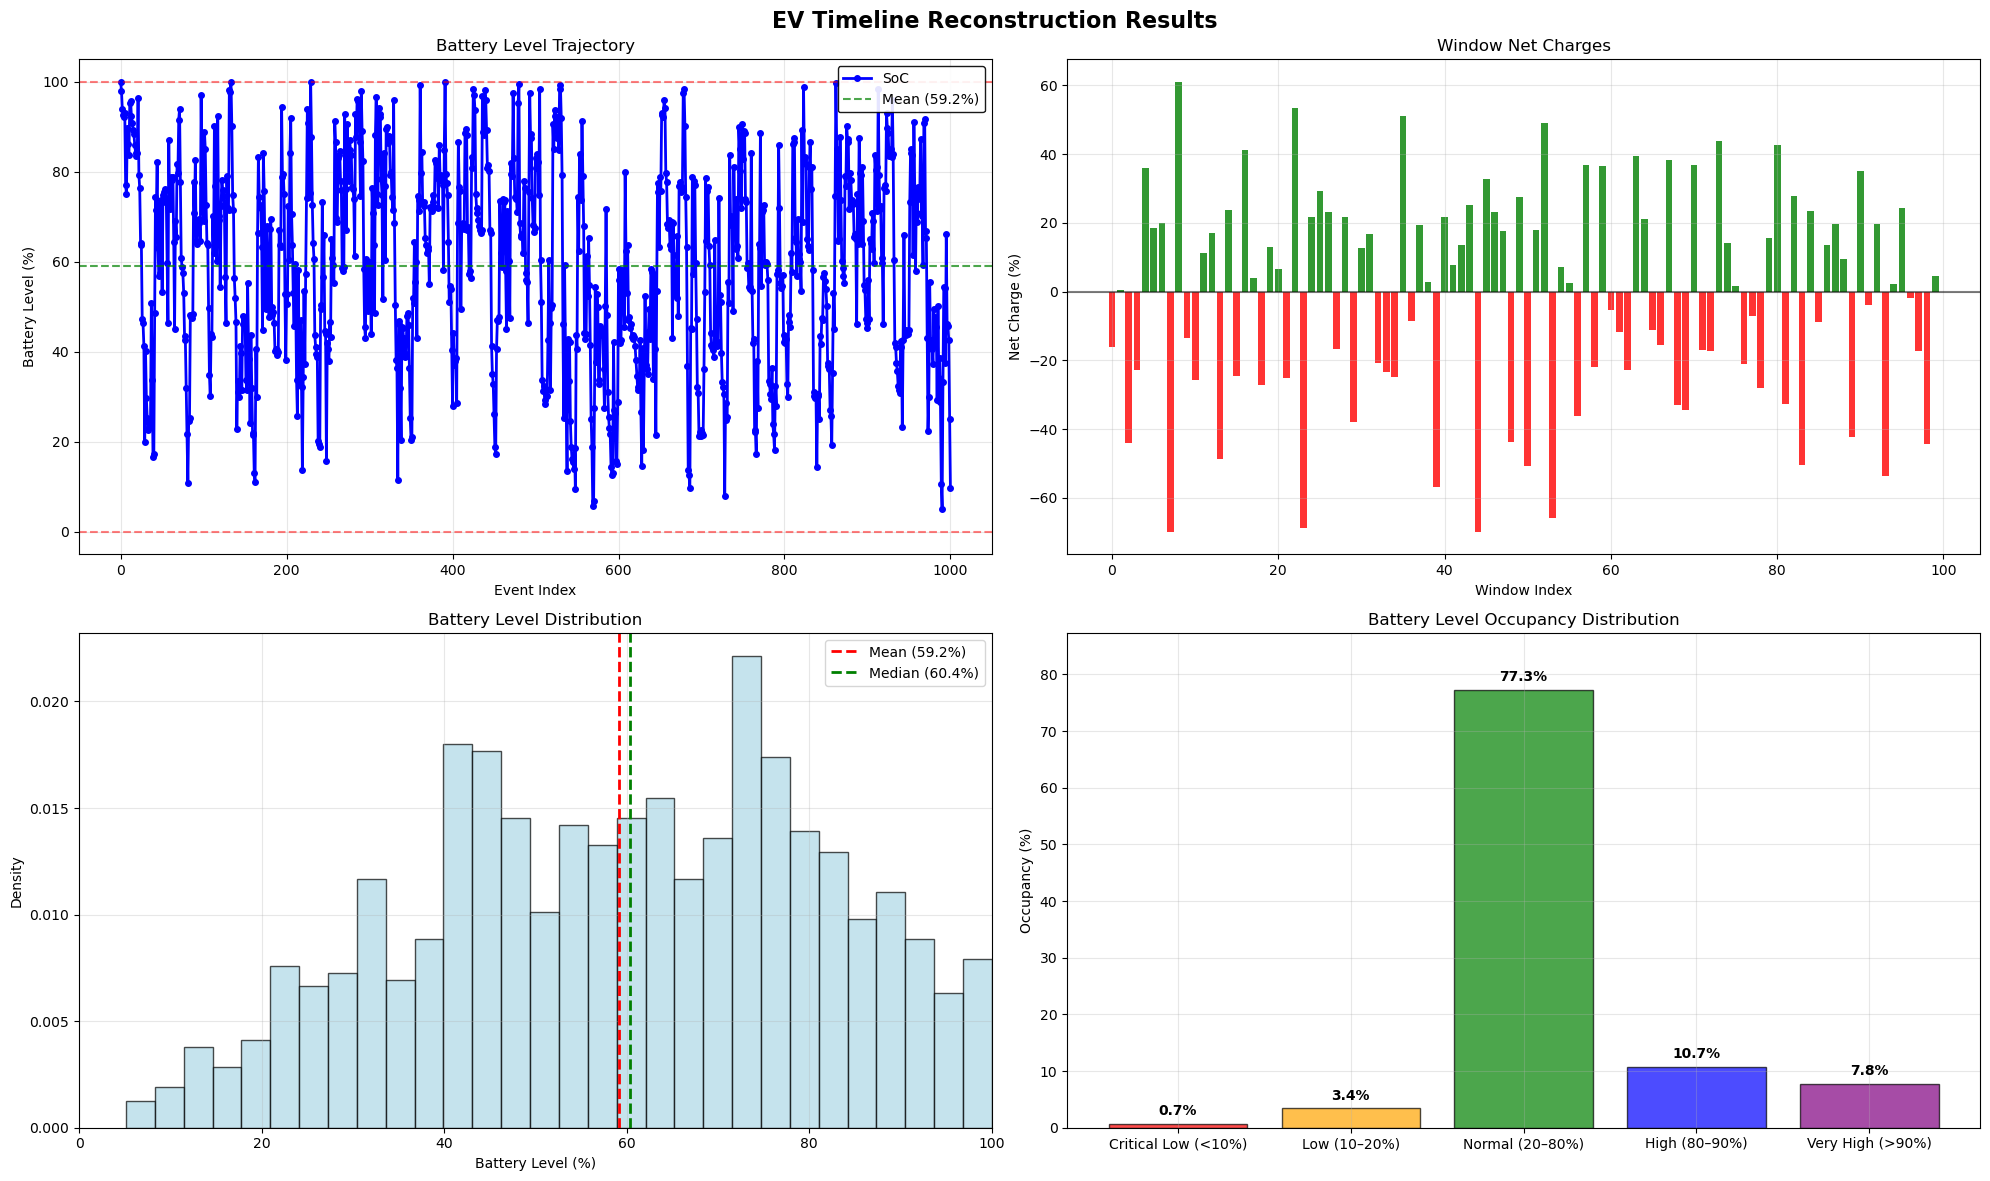


Sequence Analysis:
  Window sequence: [34, 45, 10, 26, 81, 63, 67, 0, 93, 36, 20, 56, 65, 8, 74, 23, 87, 50, 19, 58, 52, 21, 92, 2, 70, 77, 94, 33, 69, 13, 57, 61, 29, 24, 22, 91, 40, 97, 49, 4, 95, 54, 98, 79, 1, 78, 71, 64, 11, 75, 6, 62, 90, 3, 53, 48, 14, 84, 27, 82, 42, 37, 25, 86, 68, 38, 35, 85, 16, 15, 83, 31, 32, 89, 59, 46, 28, 41, 18, 60, 88, 17, 76, 7, 72, 39, 99, 96, 55, 12, 80, 43, 66, 5, 47, 73, 44, 30, 9, 51]
  Sequence length: 100
  Battery stability (low std is better): 21.98%
  Time in critical low battery (<10%): 0.7%
  Time in low battery (10–20%): 3.4%
  Time in normal battery zone (20–80%): 77.3%
  Time in high zone (80–90%): 10.7%
  Time in very high zone (>90%): 7.9%
  Charging windows: 55, Discharging windows: 45
  Total net charge: -90.3%

DETAILED VIOLATION ANALYSIS
ℹ️  Position 0 → 1: Window 34 doesn't end with charge, Window 45 starts with 120
ℹ️  Position 1 → 2: Window 45 doesn't end with charge, Window 10 starts with 240
ℹ️  Position 2 → 3: Window 10 en

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import random
from typing import List, Tuple, Dict, Optional, Set
import heapq
from dataclasses import dataclass

random.seed(2025)
np.random.seed(2025)
target_mean = 100

@dataclass
class BatteryState:
    """Represents battery state at a point in time"""
    level: float  # Battery percentage (0-100)
    timestamp: int  # Relative time
    window_id: int  # Which window this state belongs to
    event_idx: int  # Position within window

class EVTimelineReconstructor:
    """
    Algorithm to reconstruct EV timeline from fragmented windows
    while respecting battery constraints (0% ≤ battery ≤ 100%)
    """
    
    def __init__(self, windows: List[pd.DataFrame], initial_battery_range=(0, 100),
                 min_soc: float = 0.0,
                 max_soc: float = 100.0,
                 different_mode_penalty: float = 10000.0,
                 # Tuning parameters for extreme windows
                 low_soc_threshold: float = 25.0,
                 high_soc_threshold: float = 75.0,
                 extreme_netcharge_threshold: float = 35.0,
                 preference_bonus: float = 500.0):
        """Initialize the reconstructor"""
        self.windows = windows
        self.n_windows = len(windows)
        self.initial_battery_range = initial_battery_range
        self.window_net_charges = [w['charge'].sum() for w in windows]

        self.min_soc = min_soc
        self.max_soc = max_soc
        self.different_mode_penalty = different_mode_penalty

        self.low_soc_threshold = low_soc_threshold
        self.high_soc_threshold = high_soc_threshold
        self.extreme_netcharge_threshold = extreme_netcharge_threshold
        self.preference_bonus = preference_bonus
        
        print(f"🔋 Initializing timeline reconstructor with {self.n_windows} windows")
        print(f"Window net charges: {[f'{x:.1f}%' for x in self.window_net_charges]}")
        print("Total net charge across all windows:", sum(self.window_net_charges))
        
        self.precompute_window_stats()

        
    def precompute_window_stats(self):
        """Precompute statistics for each window"""
        self.window_stats = []
        
        for i, window in enumerate(self.windows):
            stats = {
                'window_id': i,
                'net_charge': window['charge'].sum(),
                'min_intermediate_charge': 0,
                'max_intermediate_charge': 0,
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'charge_events': (window['charge'] > 0).sum(),
                'discharge_events': (window['charge'] < 0).sum()
            }
            
            running_charge = 0
            min_charge, max_charge = 0, 0
            
            for charge in window['charge']:
                running_charge += charge
                min_charge = min(min_charge, running_charge)
                max_charge = max(max_charge, running_charge)
            
            stats['min_intermediate_charge'] = min_charge
            stats['max_intermediate_charge'] = max_charge
            
            self.window_stats.append(stats)

    def simulate_battery_trace(self, sequence: List[int], start_battery: float) -> List[float]:
        """Return the battery trace"""
        battery = start_battery
        trace = [battery]
        for window_id in sequence:
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
        return trace

    def preference_bonus_for_placement(self, battery_before: float, net_charge: float) -> float:
        """
        Return a negative cost (bonus) if placement is sensible:
          - Low battery + high positive charge = bonus
          - High battery + high negative charge = bonus
        Otherwise return penalty for bad placements
        """
        if abs(net_charge) < self.extreme_netcharge_threshold:
            return 0.0

        scale = abs(net_charge) / max(self.extreme_netcharge_threshold, 1.0)
        
        # Good placements (bonus)
        if battery_before <= self.low_soc_threshold and net_charge > 0:
            return -self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge < 0:
            return -self.preference_bonus * scale

        # Bad placements (penalty)
        if battery_before <= self.low_soc_threshold and net_charge < 0:
            return self.preference_bonus * scale
        if battery_before >= self.high_soc_threshold and net_charge > 0:
            return self.preference_bonus * scale

        return 0.0

    def window_ends_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window ends with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        last_event = w.iloc[-1]
        if last_event.get('event') == 'charge':
            return str(last_event.get('charge_mode'))
        return None
    
    
    def window_starts_with_charge_mode(self, window_id: int) -> Optional[str]:
        """Return the charge_mode if window starts with a charge, else None"""
        w = self.windows[window_id]
    
        # Safety check: empty window
        if w.empty:
            return None
    
        first_event = w.iloc[0]
        if first_event.get('event') == 'charge':
            return str(first_event.get('charge_mode'))
        return None

    
    def check_consecutive_different_mode_violation(self, sequence: List[int]) -> Tuple[bool, int]:
        """Check if sequence has consecutive DIFFERENT-mode charge violations"""
        violations = 0
        for i in range(len(sequence) - 1):
            end_mode = self.window_ends_with_charge_mode(sequence[i])
            start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
            
            if end_mode is not None and start_mode is not None and end_mode != start_mode:
                violations += 1
        
        return violations > 0, violations

    def algorithm_2_simulated_annealing(self, start_battery: float, 
                                      max_iterations: int = 20000,
                                      initial_temp: float = 100.0) -> Optional[List[int]]:
        """Standard Simulated Annealing """
        print("  Running Algorithm: Simulated Annealing...")
        
        def evaluate_sequence(sequence: List[int]) -> float:
            """Evaluate fitness with EXPONENTIAL penalties and preference bonuses"""
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(sequence):
                stats = self.window_stats[window_id]

                # Different-mode penalty
                if i > 0:
                    prev_id = sequence[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Check constraints with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)  # EXPONENTIAL
                
                # Preference bonus/penalty
                pref = self.preference_bonus_for_placement(battery, stats['net_charge'])
                cost += pref
                
                battery += stats['net_charge']
                cost += abs(battery - target_mean) * 0.05
            
            return cost
        
        def get_smart_neighbor(sequence: List[int]) -> List[int]:
            """Smart neighbor generation that targets problem areas"""
            
            # 30% of time: use constraint-aware swapping
            if random.random() < 0.3:
                battery = start_battery
                problem_positions = []
                
                for i, window_id in enumerate(sequence):
                    stats = self.window_stats[window_id]
                    min_battery = battery + stats['min_intermediate_charge']
                    max_battery = battery + stats['max_intermediate_charge']
                    
                    if min_battery < 0.0 or max_battery > self.max_soc:
                        problem_positions.append(i)
                    
                    battery += stats['net_charge']
                
                if problem_positions:
                    new_seq = sequence.copy()
                    problem_idx = random.choice(problem_positions)
                    window_id = sequence[problem_idx]
                    stats = self.window_stats[window_id]
                    
                    # Move high-charge windows earlier, high-discharge later
                    if stats['net_charge'] > self.extreme_netcharge_threshold:
                        new_pos = random.randint(0, max(1, len(new_seq) // 3))
                    elif stats['net_charge'] < -self.extreme_netcharge_threshold:
                        new_pos = random.randint(2 * len(new_seq) // 3, len(new_seq) - 1)
                    else:
                        new_pos = random.randint(0, len(new_seq) - 1)
                    
                    new_seq.insert(new_pos, new_seq.pop(problem_idx))
                    return new_seq
            
            # 30% of time: mode-aware swapping
            if random.random() < 0.5:
                has_violation, _ = self.check_consecutive_different_mode_violation(sequence)
                
                if has_violation:
                    violation_positions = []
                    for i in range(len(sequence) - 1):
                        end_mode = self.window_ends_with_charge_mode(sequence[i])
                        start_mode = self.window_starts_with_charge_mode(sequence[i + 1])
                        if end_mode is not None and start_mode is not None and end_mode != start_mode:
                            violation_positions.append(i)
                    
                    if violation_positions:
                        new_seq = sequence.copy()
                        violation_pos = random.choice(violation_positions)
                        other_pos = random.choice([p for p in range(len(new_seq)) 
                                                   if p not in [violation_pos, violation_pos + 1]])
                        new_seq[violation_pos + 1], new_seq[other_pos] = new_seq[other_pos], new_seq[violation_pos + 1]
                        return new_seq
            
            # Standard moves
            neighbor_type = random.choice(['swap', 'insert'])
            new_seq = sequence.copy()
            
            if neighbor_type == 'insert':
                i = random.randint(0, len(new_seq) - 1)
                element = new_seq.pop(i)
                j = random.randint(0, len(new_seq))
                new_seq.insert(j, element)
            else:  # swap
                i, j = random.sample(range(len(new_seq)), 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            
            return new_seq
        
        # Main SA loop
        current_sequence = list(range(self.n_windows))
        random.shuffle(current_sequence)
        current_cost = evaluate_sequence(current_sequence)
        
        best_sequence = current_sequence.copy()
        best_cost = current_cost
        
        temp = initial_temp
        
        for iteration in range(max_iterations):
            neighbor = get_smart_neighbor(current_sequence)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_sequence = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_sequence = current_sequence.copy()
                    best_cost = current_cost
            
            temp *= 0.995
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"  Final best cost: {best_cost:.2f}")
        
        if best_sequence:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_sequence)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_sequence if best_cost < float('inf') else None

    def algorithm_anchored_sa(self, start_battery: float,
                              stage1_iters: int = 15000,
                              stage2_iters: int = 40000,
                              initial_temp: float = 150.0) -> Optional[List[int]]:
        """
        Fixed Two-stage Anchored Simulated Annealing:
        1. Identify extreme windows
        2. Place them in sensible positions (anchors)
        3. Optimize placement of non-extreme windows around them
        """
        
        print("  Stage 1: Identifying and placing extreme windows...")
        
        # Identify extreme windows
        extreme_windows = []
        normal_windows = []
        
        for window_id, stats in enumerate(self.window_stats):
            if abs(stats['net_charge']) > self.extreme_netcharge_threshold:
                extreme_windows.append({
                    'id': window_id,
                    'net_charge': stats['net_charge'],
                    'stats': stats
                })
            else:
                normal_windows.append(window_id)
        
        print(f"  Found {len(extreme_windows)} extreme windows:")
        for ew in extreme_windows:
            print(f"    Window {ew['id']}: net_charge = {ew['net_charge']:.1f}%")
        print(f"  Found {len(normal_windows)} normal windows")
        
        if not extreme_windows:
            print("  No extreme windows found, using standard SA")
            return self.algorithm_2_simulated_annealing(start_battery, stage1_iters + stage2_iters, initial_temp)
        
        # Sort extreme windows: positive first (to charge early), then negative (to discharge late)
        extreme_windows.sort(key=lambda x: -x['net_charge'])
        

        def place_extremes_interleaved() -> Tuple[List[int], Dict[int,int]]:
            """
            Place extreme windows by interleaving positive and negative extremes, roughly evenly spaced.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # Separate extreme windows into pos / neg and sort by magnitude
            pos_extremes = [ew for ew in extreme_windows if ew['net_charge'] > 0]
            neg_extremes = [ew for ew in extreme_windows if ew['net_charge'] < 0]
        
            pos_extremes.sort(key=lambda x: -x['net_charge'])   # largest positive first
            neg_extremes.sort(key=lambda x: x['net_charge'])    # most negative first (i.e. smallest value)
        
            total_extremes = len(pos_extremes) + len(neg_extremes)
            if total_extremes == 0:
                # fall back
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # Determine starting sign: if start battery low => start with positive; if high => start with negative;
            # otherwise choose sign that has the largest total magnitude (helps place big chargers/dischargers earlier)
            total_pos = sum(abs(e['net_charge']) for e in pos_extremes)
            total_neg = sum(abs(e['net_charge']) for e in neg_extremes)
        
            if start_battery <= self.low_soc_threshold:
                start_with_pos = True
            elif start_battery >= self.high_soc_threshold:
                start_with_pos = False
            else:
                start_with_pos = total_pos >= total_neg
        
            # Build interleaved order from the two lists
            interleaved = []
            p_idx, n_idx = 0, 0
            turn_pos = start_with_pos
        
            while p_idx < len(pos_extremes) or n_idx < len(neg_extremes):
                if turn_pos and p_idx < len(pos_extremes):
                    interleaved.append(pos_extremes[p_idx])
                    p_idx += 1
                elif (not turn_pos) and n_idx < len(neg_extremes):
                    interleaved.append(neg_extremes[n_idx])
                    n_idx += 1
                else:
                    # one list exhausted: drain the other
                    if p_idx < len(pos_extremes):
                        interleaved.append(pos_extremes[p_idx]); p_idx += 1
                    elif n_idx < len(neg_extremes):
                        interleaved.append(neg_extremes[n_idx]); n_idx += 1
                # alternate turn
                turn_pos = not turn_pos
        
            # Decide target positions: evenly spaced across the sequence, but avoid edges:
            avoid_edges = True            # param: set False if you *do* want edges
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=len(interleaved))
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=len(interleaved))
        
            # Place each extreme roughly at its target position, with small jitter and enforcing a min_gap
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th of sequence or more
            occupied = set()
        
            for idx, (ew, posf) in enumerate(zip(interleaved, positions_float)):
                # rounded target
                target = int(round(posf))
        
                # add small jitter up to +-min_gap//2
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # find nearest free slot that respects min_gap from already placed extremes
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                # try target, then expand outwards up to windows length
                placed = False
                for d in range(0, self.n_windows):
                    # try left then right at distance d
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
                # if we couldn't respect min_gap, place anywhere free (last resort)
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # Fill remaining slots with normal windows in original order (or you can shuffle)
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]  # fallback - shouldn't happen
        
            # Trim any possible -1 (defensive)
            sequence = [w for w in sequence if w != -1]
        
            return sequence, extreme_positions

        def place_extremes_balanced() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced across the sequence (no forced +/− alternation).
            Higher-magnitude extremes are placed first, regardless of sign.
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Combine and sort all extremes by absolute magnitude descending ---
            all_extremes = sorted(extreme_windows, key=lambda x: abs(x['net_charge']), reverse=True)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                # fallback: fill with normal windows in order
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Determine evenly spaced target positions (avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
        
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))  # roughly 1/10th or more of sequence
            occupied = set()
        
            # --- Place each extreme roughly at its target position ---
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                # add small jitter (+/- min_gap//2)
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                # helper to check valid slot
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                # fallback: place anywhere free
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        def place_extremes_randomized() -> Tuple[List[int], Dict[int, int]]:
            """
            Place extreme windows roughly evenly spaced, 
            but assign them to positions in random order (maximize randomness).
            Returns (sequence, extreme_positions)
            """
            sequence = [-1] * self.n_windows
            extreme_positions = {}
        
            # --- Randomize order of extremes ---
            all_extremes = extreme_windows.copy()
            np.random.shuffle(all_extremes)
            total_extremes = len(all_extremes)
        
            if total_extremes == 0:
                normal_iter = iter(normal_windows)
                for i in range(len(sequence)):
                    sequence[i] = next(normal_iter)
                return [w for w in sequence if w != -1], {}
        
            # --- Keep same structured positions (evenly spaced, avoid edges) ---
            avoid_edges = True
            edge_margin = max(1, int(self.n_windows * 0.05)) if avoid_edges else 0
            available_span = self.n_windows - 2 * edge_margin
            if available_span <= 0:
                positions_float = np.linspace(0, self.n_windows - 1, num=total_extremes)
            else:
                positions_float = np.linspace(edge_margin, edge_margin + available_span - 1, num=total_extremes)
        
            # --- Placement parameters ---
            min_gap = max(1, int(self.n_windows / max(10, total_extremes)))
            occupied = set()
        
            # --- Assign each extreme to a random position target ---
            np.random.shuffle(positions_float)
        
            for ew, posf in zip(all_extremes, positions_float):
                target = int(round(posf))
        
                jitter = int(np.round((np.random.rand() - 0.5) * min_gap * 0.6))
                target = int(np.clip(target + jitter, 0, self.n_windows - 1))
        
                def ok_slot(t):
                    if sequence[t] != -1:
                        return False
                    for occ in occupied:
                        if abs(t - occ) < min_gap:
                            return False
                    return True
        
                placed = False
                for d in range(0, self.n_windows):
                    for cand in (target - d, target + d):
                        if 0 <= cand < self.n_windows and ok_slot(cand):
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            placed = True
                            break
                    if placed:
                        break
        
                if not placed:
                    for cand in range(self.n_windows):
                        if sequence[cand] == -1:
                            sequence[cand] = ew['id']
                            extreme_positions[ew['id']] = cand
                            occupied.add(cand)
                            break
        
            # --- Fill remaining with normal windows ---
            normal_iter = iter(normal_windows)
            for i in range(len(sequence)):
                if sequence[i] == -1:
                    try:
                        sequence[i] = next(normal_iter)
                    except StopIteration:
                        sequence[i] = normal_windows[-1]
        
            sequence = [w for w in sequence if w != -1]
            return sequence, extreme_positions

        # choose extreme placing --> 1. place_extremes_interleaved, 2. place_extremes_balanced, 3. place_extremes_randomized
        initial_sequence, anchored_positions = place_extremes_randomized()
        print(f"  Initial extreme placement complete")
        print(f"  Anchored positions: {anchored_positions}")
        
        # Evaluate initial sequence
        def evaluate_sequence(seq: List[int]) -> float:
            battery = start_battery
            cost = 0.0
            
            for i, window_id in enumerate(seq):
                stats = self.window_stats[window_id]
                
                # Different-mode penalty
                if i > 0:
                    prev_id = seq[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        cost += self.different_mode_penalty
                
                # Constraint violations with EXPONENTIAL penalties
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    violation = self.min_soc - min_battery
                    cost += 3000 * (violation ** 2)
                if max_battery > self.max_soc:
                    violation = max_battery - self.max_soc
                    cost += 3000 * (violation ** 2)
                
                # Preference bonus
                cost += self.preference_bonus_for_placement(battery, stats['net_charge'])
                
                battery += stats['net_charge']
                cost += abs(battery - target_mean) * 0.05
            
            return cost
        
        initial_cost = evaluate_sequence(initial_sequence)
        print(f"  Initial sequence cost: {initial_cost:.2f}")
        
        print("\n  Stage 2: Optimizing non-extreme window positions...")
        
        # Get set of anchored window IDs for fast lookup
        anchored_window_ids = set(anchored_positions.keys())
        
        def get_neighbor_anchored(seq: List[int]) -> List[int]:
            """Generate neighbor that only moves non-anchored windows"""
            new_seq = seq.copy()
            
            # Find indices of non-anchored windows
            movable_indices = [i for i, wid in enumerate(new_seq) if wid not in anchored_window_ids]
            
            if len(movable_indices) < 2:
                return new_seq
            
            # Choose move type
            move_type = random.choice(['swap', 'insert'])
            
            if move_type == 'swap':
                i, j = random.sample(movable_indices, 2)
                new_seq[i], new_seq[j] = new_seq[j], new_seq[i]
            else:  # insert
                i = random.choice(movable_indices)
                element = new_seq.pop(i)
                # Find valid insertion points (between/around anchors is fine)
                valid_positions = list(range(len(new_seq) + 1))
                j = random.choice(valid_positions)
                new_seq.insert(j, element)
            
            return new_seq
        
        # Stage 2 SA optimization
        current_seq = initial_sequence.copy()
        current_cost = initial_cost
        best_seq = current_seq.copy()
        best_cost = current_cost
        temp = initial_temp
        
        for iteration in range(stage2_iters):
            neighbor = get_neighbor_anchored(current_seq)
            neighbor_cost = evaluate_sequence(neighbor)
            
            if neighbor_cost < current_cost or random.random() < np.exp(-(neighbor_cost - current_cost) / max(1e-8, temp)):
                current_seq = neighbor
                current_cost = neighbor_cost
                
                if current_cost < best_cost:
                    best_seq = current_seq.copy()
                    best_cost = current_cost
            
            temp *= 0.9995  # Slower cooling
            
            if iteration % 1000 == 0:
                print(f"  Iteration {iteration}: Best cost = {best_cost:.2f}, Temp = {temp:.2f}")
        
        print(f"\n✅ Anchored SA finished. Best cost: {best_cost:.2f}")
        
        if best_seq:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_seq)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_seq

    def reconstruct_timeline(self, start_battery: Optional[float] = None) -> Dict:
        """Main method to reconstruct timeline"""
        print("🔄 Starting EV Timeline Reconstruction...")
        print("="*60)
        
        if start_battery is None:
            start_battery = np.mean(self.initial_battery_range)

        if start_battery < self.min_soc or start_battery > self.max_soc:
            print(f"⚠️  Warning: start_battery ({start_battery}%) outside bounds [{self.min_soc}%, {self.max_soc}%]")
            start_battery = np.clip(start_battery, self.min_soc, self.max_soc)
            print(f"   Adjusted to: {start_battery}%")
        
        print(f"Starting battery level: {start_battery:.1f}%")
        print(f"Different-mode penalty: {self.different_mode_penalty}")
        
        solutions = {}
        
        algorithms = [
            #("Standard SA (Enhanced)", self.algorithm_2_simulated_annealing),
            ("Anchored SA (2-stage)", self.algorithm_anchored_sa)
        ]
        
        for name, algorithm in algorithms:
            try:
                solution = algorithm(start_battery)
                if solution:
                    is_valid, final_battery, violation_idx, trace = self.validate_solution(solution, start_battery)
                    has_violation, num_violations = self.check_consecutive_different_mode_violation(solution)
                    
                    if is_valid:
                        solutions[name] = {
                            'sequence': solution,
                            'final_battery': final_battery,
                            'trace': trace,
                            'score': self.score_solution(solution, start_battery),
                            'different_mode_violations': num_violations
                        }
                        violation_msg = f" (⚠️ {num_violations} different-mode violations)" if has_violation else " (✅ no violations)"
                        print(f"✅ {name}: Valid solution found (final battery: {final_battery:.1f}%){violation_msg}")
                    else:
                        print(f"❌ {name}: Invalid solution — violation at window {violation_idx}")
                        print("Running invalid solution diagnosis...")
                        self.diagnose_invalid_solution(solution, start_battery)
                        
                        if violation_idx is not None and violation_idx > 0:
                            partial_sequence = solution[:violation_idx]
                            print(f"Using partial valid timeline of {len(partial_sequence)} windows for visualization.")
                            
                            solutions[name] = {
                                'sequence': partial_sequence,
                                'final_battery': final_battery,
                                'trace': trace,
                                'score': self.score_solution(partial_sequence, start_battery),
                                'different_mode_violations': num_violations
                            }
                else:
                    print(f"❌ {name}: No solution found")
            except Exception as e:
                import traceback
                print(f"❌ {name}: Error - {e}")
                traceback.print_exc()
        
        if not solutions:
            print("❌ No valid solutions found!")
            return {'best_solution': None}
        
        def solution_key(name):
            sol = solutions[name]
            return (sol['different_mode_violations'], sol['score'])
        
        best_name = min(solutions.keys(), key=solution_key)
        best_solution = solutions[best_name]
        
        print(f"\n🏆 Best solution: {best_name}")
        print(f"Sequence: {best_solution['sequence']}")
        print(f"Final battery: {best_solution['final_battery']:.1f}%")
        print(f"Different-mode violations: {best_solution['different_mode_violations']}")
        
        return {
            'best_solution': best_solution,
            'all_solutions': solutions,
            'start_battery': start_battery
        }

    def validate_solution(self, sequence: List[int], start_battery: float):
        """Validate solution and return trace"""
        battery = start_battery
        trace = [battery]
        for idx, window_id in enumerate(sequence):
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
                if battery < 0.0 or battery > self.max_soc:
                    return False, battery, idx, trace
        return True, battery, None, trace

    def diagnose_invalid_solution(self, sequence: List[int], start_battery: float):
        """Diagnostic visualization for invalid sequences"""
        battery = start_battery
        trace = [battery]
        violating_window = None
        violation_type = None
        violation_index = None

        for idx, window_id in enumerate(sequence):
            window = self.windows[window_id]
            for _, event in window.iterrows():
                battery += event['charge']
                trace.append(battery)
                if battery < 0.0 or battery > self.max_soc:
                    violating_window = window_id
                    violation_type = "LOW" if battery < 0.0 else "HIGH"
                    violation_index = len(trace) - 1
                    break
            if violating_window is not None:
                break

        if violating_window is None:
            print("⚠️ No violation found")
            return

        print("\n🚨 DIAGNOSIS: INVALID SOLUTION DETECTED 🚨")
        print(f" Violation type: Battery went too {violation_type}")
        print(f" Violating window ID: {violating_window}")
        print(f" Net charge of violating window: {self.window_stats[violating_window]['net_charge']:.1f}%")
        print(f" Battery before violation: {trace[violation_index-1]:.1f}% → after: {trace[violation_index]:.1f}%")
        print(f" Allowed range: [{self.min_soc:.1f}%, {self.max_soc:.1f}%]")
        
        partial_seq = sequence[:sequence.index(violating_window)+1]
        net_charges = [self.window_stats[i]['net_charge'] for i in partial_seq]
        windows_idx = np.arange(len(partial_seq))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Diagnostic of Invalid EV Timeline', fontsize=16, fontweight='bold')

        axes[0].plot(trace, marker='o', color='blue', label='Battery SoC')
        axes[0].axhline(y=0, color='red', linestyle='--', label=f'Min SoC (0%)')
        axes[0].axhline(y=self.max_soc, color='red', linestyle='--', label=f'Max SoC ({self.max_soc}%)')
        axes[0].axvline(x=violation_index, color='orange', linestyle=':', label='Violation point')
        axes[0].set_xlabel('Event Index')
        axes[0].set_ylabel('Battery Level (%)')
        axes[0].set_title('Battery Level Evolution (until violation)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        colors = ['green' if nc > 0 else 'red' for nc in net_charges]
        axes[1].bar(windows_idx, net_charges, color=colors, alpha=0.8)
        axes[1].axhline(y=0, color='black', linestyle='--')
        axes[1].axvline(x=windows_idx[-1], color='orange', linestyle=':', label='Violation window')
        axes[1].set_xlabel('Window (sequence order)')
        axes[1].set_ylabel('Net Charge (%)')
        axes[1].set_title('Net Charge per Window (until violation)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        if violation_type == "HIGH":
            print("🟢 Interpretation:")
            print("  → The sequence caused excessive CHARGING near the top SoC limit.")
            print("  → Try placing high positive net-charge windows earlier or after discharge-heavy windows.")
        else:
            print("🔴 Interpretation:")
            print("  → The sequence drained the battery below the minimum SoC.")
            print("  → Consider moving discharge-heavy (negative net-charge) windows later in the sequence.")
        
        print(f"\n📊 Sequence net charge statistics up to violation:")
        print(f"  • Mean net charge: {np.mean(net_charges):.2f}%")
        print(f"  • Std deviation  : {np.std(net_charges):.2f}%")
        print(f"  • Total net charge accumulated: {sum(net_charges):.2f}%")

    def score_solution(self, sequence: List[int], start_battery: float) -> float:
        """Score a solution (lower is better)"""
        _, final_battery, _, trace = self.validate_solution(sequence, start_battery)
        
        score = sum(abs(b - target_mean) for b in trace) / len(trace)
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        score += num_violations * 1000
        
        if 20 <= final_battery <= 80:
            score -= 10
        
        return score
    
    def visualize_reconstruction(self, result: Dict, figsize=(20, 12)):
        """Visualize the reconstruction results."""
        if result['best_solution'] is None:
            print("No solution to visualize!")
            return
        
        best_sol = result['best_solution']
        sequence = best_sol['sequence']
        trace = np.array(best_sol['trace'])  
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('EV Timeline Reconstruction Results', fontsize=16, fontweight='bold')
        
        # --- Battery statistics ---
        mean_soc = np.mean(trace)
        median_soc = np.median(trace)
        std_soc = np.std(trace, ddof=1)
        
        print(f"\nBattery SOC Statistics:")
        print(f"  Mean   : {mean_soc:.2f}%")
        print(f"  Median : {median_soc:.2f}%")
        print(f"  Std Dev: {std_soc:.2f}%")
        print(f"  Range  : {min(trace):.1f}% - {max(trace):.1f}%")
        
        has_violation, num_violations = self.check_consecutive_different_mode_violation(sequence)
        print(f"  Different-mode violations: {num_violations}")
        
        # --- 1. Battery level trajectory ---
        axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SoC')
        axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=self.max_soc, color='red', linestyle='--', alpha=0.5)
        axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
        axes[0,0].set_ylabel('Battery Level (%)')
        axes[0,0].set_xlabel('Event Index')
        axes[0,0].set_title('Battery Level Trajectory')
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')
    
        # --- 2. Window sequence net charges ---
        window_charges = [self.window_stats[i]['net_charge'] for i in sequence]
        colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_charges]
        axes[0,1].bar(range(len(sequence)), window_charges, color=colors, alpha=0.8)
        axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
        axes[0,1].set_xlabel('Window Index')
        axes[0,1].set_ylabel('Net Charge (%)')
        axes[0,1].set_title('Window Net Charges')
        axes[0,1].grid(True, alpha=0.3)

        # --- 3. Battery SoC distribution ---
        axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
        axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
        axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
        axes[1,0].set_xlabel('Battery Level (%)')
        axes[1,0].set_ylabel('Density')
        axes[1,0].set_title('Battery Level Distribution')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].set_xlim([0, 100])
    
        # --- 4. Battery occupancy levels ---
        categories = {
            "Critical Low (<10%)": (0, 10),
            "Low (10–20%)": (10, 20),
            "Normal (20–80%)": (20, 80),
            "High (80–90%)": (80, 90),
            "Very High (>90%)": (90, 100)
        }
    
        counts = {}
        total = len(trace)
        for label, (low, high) in categories.items():
            counts[label] = np.sum((trace >= low) & (trace < high)) / total * 100 
    
        colors_occ = ['red', 'orange', 'green', 'blue', 'purple']
        axes[1,1].bar(counts.keys(), counts.values(), color=colors_occ, alpha=0.7, edgecolor='black')
        axes[1,1].set_ylabel('Occupancy (%)')
        axes[1,1].set_title('Battery Level Occupancy Distribution')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].set_ylim(0, max(counts.values()) + 10)
    
        for i, (label, value) in enumerate(counts.items()):
            axes[1,1].text(i, value + 1, f"{value:.1f}%", ha='center', va='bottom', fontweight='bold')
    
        
    
        plt.tight_layout()
        plt.show()
        
        # --- Print stats ---
        print(f"\nSequence Analysis:")
        print(f"  Window sequence: {sequence}")
        print(f"  Sequence length: {len(sequence)}")
        print(f"  Battery stability (low std is better): {std_soc:.2f}%")
        print(f"  Time in critical low battery (<10%): {np.sum(trace < 10)/total*100:.1f}%")
        print(f"  Time in low battery (10–20%): {np.sum((trace >= 10) & (trace < 20))/total*100:.1f}%")
        print(f"  Time in normal battery zone (20–80%): {np.sum((trace >= 20) & (trace <= 80))/total*100:.1f}%")
        print(f"  Time in high zone (80–90%): {np.sum((trace > 80) & (trace < 90))/total*100:.1f}%")
        print(f"  Time in very high zone (>90%): {np.sum(trace >= 90)/total*100:.1f}%")
    
        positive_windows = np.sum(np.array(window_charges) > 0)
        negative_windows = np.sum(np.array(window_charges) < 0)
        print(f"  Charging windows: {positive_windows}, Discharging windows: {negative_windows}")
        print(f"  Total net charge: {np.sum(window_charges):.1f}%")



# Demo execution
if __name__ == "__main__":
    
    # Load the CSV
    df = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin1/selected_windows_balanced.csv')
    #df = pd.read_csv('./selected_windows_balanced.csv')
   
    
    # Define window size
    seq_len = 10
    
    # Split into a list of DataFrames
    dfs = [df.iloc[i:i+seq_len] for i in range(0, 1000, seq_len)]
    #dfs = [w for w in dfs if (w['charge'].sum() >= -38 and w['charge'].sum() <= 35)]
    
    # Initialize reconstructor
    reconstructor = EVTimelineReconstructor(
        dfs, 
        initial_battery_range=(0, 100),
        min_soc=4.9,
        max_soc=100.0,
        different_mode_penalty=10000.0,
        extreme_netcharge_threshold=35.0,  # Threshold for "extreme" windows
        preference_bonus=1000.0  # Bonus for good placements
    )
    
    # Reconstruct timeline
    result = reconstructor.reconstruct_timeline(start_battery=100.0)
    
    # Visualize results
    reconstructor.visualize_reconstruction(result)
    
    # Print detailed violation analysis
    if result['best_solution'] is not None:
        best_seq = result['best_solution']['sequence']
        print("\n" + "="*60)
        print("DETAILED VIOLATION ANALYSIS")
        print("="*60)
        
        for i in range(len(best_seq) - 1):
            current_window = best_seq[i]
            next_window = best_seq[i + 1]
            
            end_mode = reconstructor.window_ends_with_charge_mode(current_window)
            start_mode = reconstructor.window_starts_with_charge_mode(next_window)
            
            if end_mode is not None and start_mode is not None:
                if end_mode != start_mode:
                    print(f"⚠️  VIOLATION at position {i} → {i+1}:")
                    print(f"   Window {current_window} ends with {end_mode} charge")
                    print(f"   Window {next_window} starts with {start_mode} charge")
                    print(f"   Mode transition: {end_mode} → {start_mode}")
                else:
                    print(f"✅ OK at position {i} → {i+1}: {end_mode} → {start_mode} (same mode)")
            elif end_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} ends with {end_mode}, Window {next_window} doesn't start with charge")
            elif start_mode is not None:
                print(f"ℹ️  Position {i} → {i+1}: Window {current_window} doesn't end with charge, Window {next_window} starts with {start_mode}")
        
        print("="*60) 

### Check consecutive charges presence (IMPROVE BY MAKE IT A FUNCTION THAT RETURN TRUE OR FALSE DEPENDING ON CHECK PASSED OR NOT): DECIDE WHAT TO DO IF CHECK NOT PASSED

In [5]:
indexes = result['best_solution']['sequence']
reconstructed_dataset = [dfs[i] for i in indexes]

df = pd.concat(reconstructed_dataset, ignore_index=True)


# Identify consecutive 'charge' groups
df['is_charge'] = (df['event'].eq('charge')) & (df['charge_mode'].ne(0))
df['charge_group'] = (df['is_charge'] & ~df['is_charge'].shift(fill_value=False)).cumsum()
df.loc[~df['is_charge'], 'charge_group'] = None

# Aggregate consecutive charge sessions
sessions = (
    df.dropna(subset=['charge_group'])
      .groupby('charge_group')
      .agg(
          session_length=('event', 'count'),
          charge_modes=('charge_mode', lambda x: list(x)),
          unique_modes=('charge_mode', lambda x: set(x))
      )
)

# Filter only sessions with multiple consecutive charges
multi_sessions = sessions[sessions['session_length'] > 1]

print("All charging sessions:")
print(sessions)

print("\nMultiple consecutive charging sessions:")
print(multi_sessions)

# Count frequency of different types of multi sessions
counts = multi_sessions['unique_modes'].value_counts()
print("\nCounts of different charge_mode combinations:")
print(counts)

All charging sessions:
              session_length charge_modes unique_modes
charge_group                                          
1.0                        1        [120]        {120}
2.0                        1        [120]        {120}
3.0                        1        [240]        {240}
4.0                        1        [240]        {240}
5.0                        1        [240]        {240}
...                      ...          ...          ...
219.0                      1        [240]        {240}
220.0                      1        [120]        {120}
221.0                      1        [120]        {120}
222.0                      2   [120, 120]        {120}
223.0                      1        [240]        {240}

[223 rows x 3 columns]

Multiple consecutive charging sessions:
              session_length                charge_modes   unique_modes
charge_group                                                           
6.0                        2                  [240, 2

### Save reconstruction

In [9]:
import pandas as pd

# -----------------------------
# 1. Reconstruct dataset order
# -----------------------------
indexes = result['best_solution']['sequence']
reconstructed_dataset = [dfs[i] for i in indexes]

# Fix charge_mode 0 → 120 for charge events
for df in reconstructed_dataset:
    df.loc[(df['event'] == 'charge') & (df['charge_mode'] == 0), 'charge_mode'] = 120

# Merge all into one
merged_df = pd.concat(reconstructed_dataset, ignore_index=True)

# -----------------------------
# 2. SoC reconstruction
# -----------------------------
start_battery = 100.0

# soc = battery before applying current charge
merged_df["soc"] = merged_df["charge"].cumsum().shift(fill_value=0) + start_battery

# end_soc = soc + ΔSoC (i.e., "charge" column)
merged_df["end_soc"] = merged_df["soc"] + merged_df["charge"]

# Drop the temporary column
merged_df = merged_df.drop(columns=["charge"])

# -----------------------------
# 3. Odometer reconstruction
# -----------------------------
start_odo = 172563.0

merged_df["odo"] = merged_df["km_driven"].cumsum().shift(fill_value=0) + start_odo
merged_df["end_odo"] = merged_df["odo"] + merged_df["km_driven"]

# Drop if unnecessary
merged_df = merged_df.drop(columns=["km_driven"])

# -----------------------------
# 4. Rounding
# -----------------------------
merged_df = merged_df.round({
    "soc": 1,
    "end_soc": 1,
    "duration_minutes": 2,
    "odo": 5,
    "end_odo": 5
})

# Replace charge mode labels for readability
merged_df["charge_mode"] = merged_df["charge_mode"].replace({360: "DC Charging"})



# -----------------------------
# 5. Group consecutive charges with same charge_mode
# -----------------------------
df = merged_df.copy()

# Identify consecutive charge blocks with same charge_mode
is_same_charge_block = (
    (df['event'] == 'charge') &
    (df['event'].shift() == 'charge') &
    (df['charge_mode'] == df['charge_mode'].shift())
)

df['group_id'] = (~is_same_charge_block).cumsum()

# Aggregate only inside same blocks
grouped = (
    df.groupby('group_id', as_index=False)
      .agg({
          'event': 'first',
          'charge_mode': 'first',
          'duration_minutes': 'sum',
          'soc': 'first',
          'end_soc': 'last',
          'odo': 'first',
          'end_odo': 'last'
      })
)

# Keep only relevant columns
final_reconstruction = grouped[['event', 'charge_mode', 'duration_minutes', 'soc', 'end_soc', 'odo', 'end_odo']]

# -----------------------------
# 6. Final rounding and export
# -----------------------------
final_reconstruction = final_reconstruction.round({
    "soc": 1,
    "end_soc": 1,
    "duration_minutes": 2,
    "odo": 5,
    "end_odo": 5
})

#Save
final_reconstruction.to_csv('./Data_saved/kl_scheduling/allRows_vin1/reconstructed_dataset_vin1.csv', index=False)

## ORIGINAL DATA - WINDOWS BEHAVIOUR

Mean SOC: 63.29%
Median SOC: 65.40%
Standard Deviation SOC: 22.14%
Min SOC: 7.80%
Max SOC: 100.00%
Minimum window net charge: -86.29999999999998
Maximum window net charge: 80.00000000000001
Mean window net charge: -6.55985401459854
Median window net charge: -7.0
Std dev window net charge: 35.213487503632315


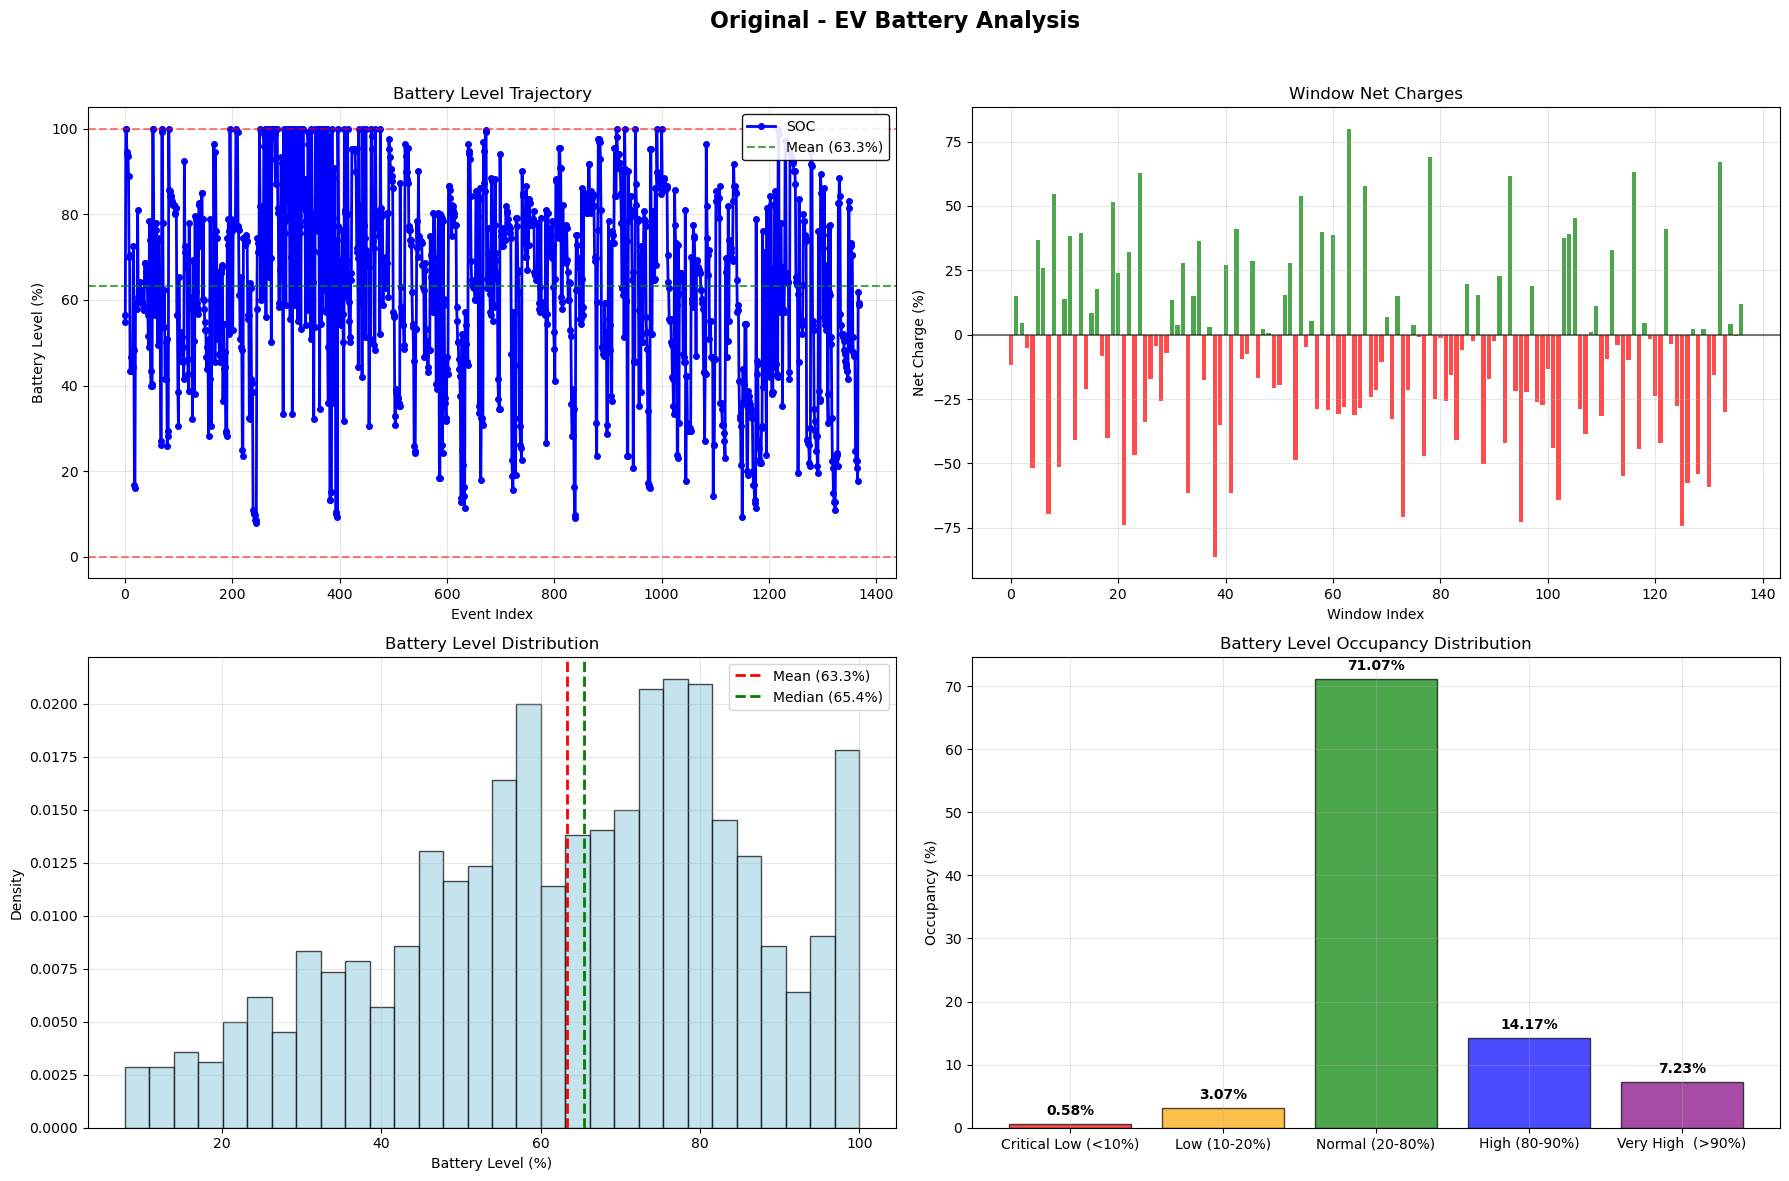

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV into DataFrame
df = pd.read_csv("./datasets/vehicle_8_99632e+18.csv")

# Extract the 'soc' column (state of charge)
df['delta_soc'] = df['end_soc'] - df['soc']
trace = df['soc']


# Compute statistics
mean_soc = trace.mean()
median_soc = trace.median()
std_soc = trace.std()
min_soc = trace.min()
max_soc = trace.max()

print(f"Mean SOC: {mean_soc:.2f}%")
print(f"Median SOC: {median_soc:.2f}%")
print(f"Standard Deviation SOC: {std_soc:.2f}%")
print(f"Min SOC: {min_soc:.2f}%")
print(f"Max SOC: {max_soc:.2f}%")

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Original - EV Battery Analysis", fontsize=16, fontweight='bold')

# 1. Battery Level Trajectory
axes[0,0].plot(trace, linewidth=2, marker='o', markersize=4, color='blue', label='SOC')
axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=100, color='red', linestyle='--', alpha=0.5)
axes[0,0].axhline(y=mean_soc, color='green', linestyle='--', alpha=0.7, label=f'Mean ({mean_soc:.1f}%)')
axes[0,0].set_xlabel("Event Index")
axes[0,0].set_ylabel("Battery Level (%)")
axes[0,0].set_title("Battery Level Trajectory")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='black')

# 2. Delta SOC between events
seq_len = 10

# Compute delta SOC
delta_soc = df['delta_soc']

# Split delta_soc into windows of length seq_len
n_windows = int(np.ceil(len(delta_soc) / seq_len))
window_sums = [
    delta_soc.iloc[i*seq_len : min((i+1)*seq_len, len(delta_soc))].sum()
    for i in range(n_windows)
]

# Main Stats
print(f'Minimum window net charge: {min(window_sums)}')
print(f'Maximum window net charge: {max(window_sums)}')
print(f'Mean window net charge: {np.mean(window_sums)}')
print(f'Median window net charge: {np.median(window_sums)}')
print(f'Std dev window net charge: {np.std(window_sums)}')


# Assign colors per window
colors_window = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in window_sums]

# Plot per window
axes[0,1].bar(range(len(window_sums)), window_sums, color=colors_window, alpha=0.7)
axes[0,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[0,1].set_xlabel("Window Index")
axes[0,1].set_ylabel("Net Charge (%)")
axes[0,1].set_title(f"Window Net Charges")
axes[0,1].grid(True, alpha=0.3)

# 3. Histogram of SOC values
axes[1,0].hist(trace, bins=30, alpha=0.7, color='lightblue', edgecolor='black', density=True)
axes[1,0].axvline(mean_soc, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_soc:.1f}%)')
axes[1,0].axvline(median_soc, color='green', linestyle='--', linewidth=2, label=f'Median ({median_soc:.1f}%)')
axes[1,0].set_xlabel("Battery Level (%)")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Battery Level Distribution")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 4. Battery Occupancy Levels
# Define categories
categories = {
    "Critical Low (<10%)": (0, 10),
    "Low (10-20%)": (10, 20),
    "Normal (20-80%)": (20, 80),
    "High (80-90%)": (80, 90),
    "Very High  (>90%)": (90, 100)
}

# Count occupancy
counts = {}
total = len(trace)
for label, (low, high) in categories.items():
    counts[label] = ((trace >= low) & (trace < high)).sum() / total * 100

# Plot occupancy as bar chart
axes[1,1].bar(counts.keys(), counts.values(),
              color=['red', 'orange', 'green', 'blue', 'purple'],
              alpha=0.7, edgecolor='black')

axes[1,1].set_ylabel("Occupancy (%)")
axes[1,1].set_title("Battery Level Occupancy Distribution")
axes[1,1].grid(True, alpha=0.3)

# Annotate values on bars
for i, (label, value) in enumerate(counts.items()):
    axes[1,1].text(i, value + 1, f"{value:.2f}%", ha='center', va='bottom', fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()


## Comparison Original VS Generated

Loaded original dataset: 137 windows of length 10
Loaded generated dataset: 100 windows of length 10
🔋 EV DATASET COMPARISON ANALYSIS REPORT
DATASET COMPARISON - BASIC STATISTICS

ORIGINAL DATASET:
----------------------------------------
Total events: 1369
Number of windows: 137
duration_minutes: μ=138.61, σ=354.60, range=[0.00, 6086.00]
km_driven: μ=21.48, σ=38.28, range=[0.00, 257.91]
charge: μ=-0.66, σ=18.04, range=[-86.70, 90.60]

GENERATED DATASET:
----------------------------------------
Total events: 1000
Number of windows: 100
duration_minutes: μ=172.32, σ=159.29, range=[49.87, 1095.59]
km_driven: μ=21.62, σ=28.73, range=[0.00, 165.46]
charge: μ=-0.09, σ=13.87, range=[-37.95, 40.54]
DATASET COMPARISON - CHARGING PATTERNS (EVENT + WINDOW LEVEL)

ORIGINAL DATASET:
------------------------------------------------------------
  EVENT-LEVEL STATS:
    Total charging: 6250.00%
    Total discharging: 7148.70%
    Net charge: -898.70%
    Charge/Discharge ratio: 0.874
  WINDOW-LEVEL S

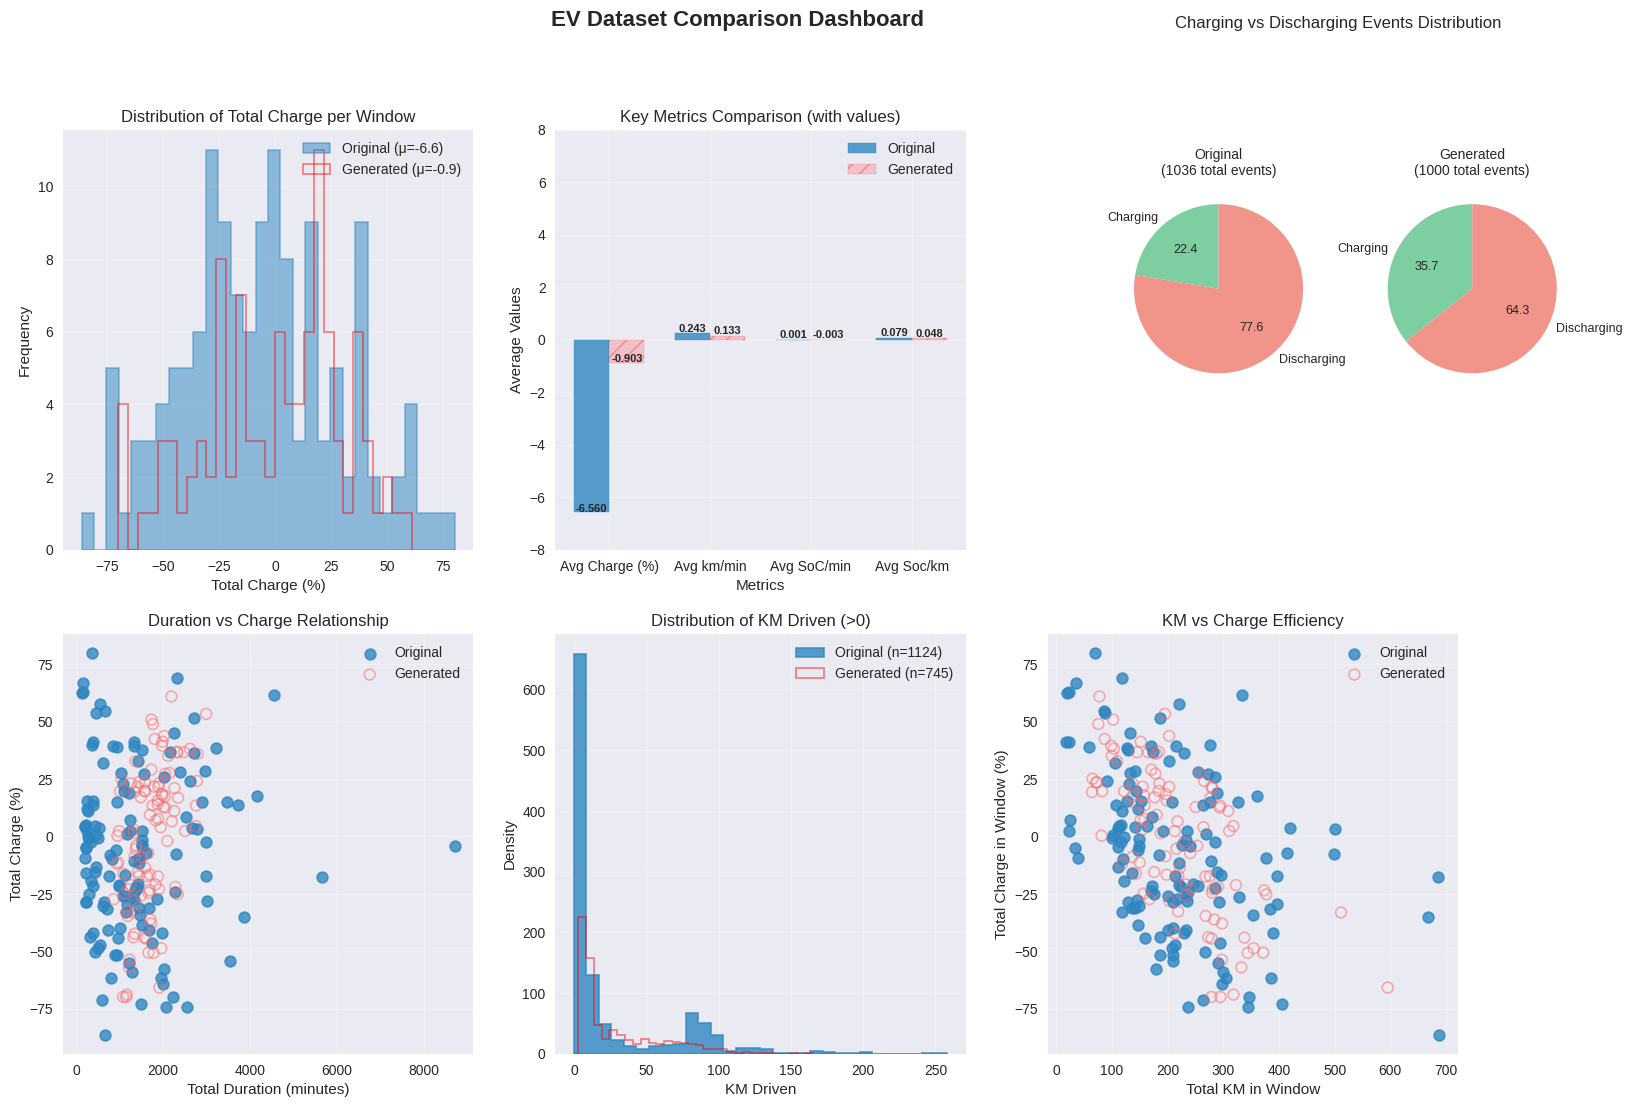

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class EVWindowComparator:
    """
    Comprehensive analyzer for comparing EV time series windows between datasets
    """
    
    def __init__(self, seq_len=10):
        """
        Initialize comparator
        
        Parameters:
        seq_len: int, sequence length of each window
        """
        self.seq_len = seq_len
        self.feature_names = ['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge']
        self.datasets = {}
        self.window_stats = {}
        
    def load_dataset(self, name, data_path=None, df=None, window_min=-100, window_max=100, start_batch=0, end_batch=None):
        """
        Load and process a dataset
        
        Parameters:
        name: str, name identifier for the dataset
        data_path: str, path to CSV file (optional if df provided)
        df: DataFrame, pre-loaded dataframe (optional if data_path provided)
        """
        if df is not None:
            processed_df = df.copy()
        elif data_path is not None:
            processed_df = pd.read_csv(data_path)
            if 'generated' in name:
                if end_batch is None:
                    end_batch = len(processed_df)
                processed_df = processed_df[start_batch:end_batch] 
        else:
            raise ValueError("Either data_path or df must be provided")
        
        # Process based on dataset type
        if name == 'original':
            processed_df['charge'] = processed_df['end_soc'] - processed_df['soc']
            processed_df['km_driven'] = processed_df['end_odo'] - processed_df['odo']
            # Convert timestamps to datetime
            processed_df['timestamp'] = pd.to_datetime(processed_df['timestamp'], errors='coerce')
            processed_df['end_time'] = pd.to_datetime(processed_df['end_time'], errors='coerce')
            # Compute event duration in minutes
            processed_df['duration_minutes'] = (processed_df['end_time'] - processed_df['timestamp']).dt.total_seconds() / 60
        
        # Split into windows
        windows = [processed_df.iloc[i:i+self.seq_len] for i in range(0, len(processed_df), self.seq_len)]
        # Filter windows with reasonable charge sums
        if 'generated' in name:
            windows = [w for w in windows if window_min <= w['charge'].sum() <= window_max and len(w) == self.seq_len]
        
        self.datasets[name] = {
            'data': processed_df,
            'windows': windows,
            'n_windows': len(windows)
        }
        
        print(f"Loaded {name} dataset: {len(windows)} windows of length {self.seq_len}")
        
    def compute_window_statistics(self, name):
        """Compute statistics for windows of a dataset"""
        windows = self.datasets[name]['windows']
        window_stats = []
        
        for i, window in enumerate(windows):
            stats_dict = {
                'window_id': i,
                'dataset': name,
                'total_charge': window['charge'].sum(),
                'net_charge': window['charge'].sum(),
                'total_duration': window['duration_minutes'].sum(),
                'total_km': window['km_driven'].sum(),
                'total_km_per_minute': window['km_driven'].sum() / window['duration_minutes'].sum(),
                'total_charge_per_minute': window['charge'].sum() / window['duration_minutes'].sum(),
                'total_charge_per_km': window['charge'].sum() / window['km_driven'].sum(),
                'n_charging_events': (window['charge'] > 0).sum(),
                'n_discharging_events': (window['charge'] < 0).sum(),
                'max_single_charge': window['charge'].max(),
                'min_single_charge': window['charge'].min(),
                'charging_efficiency': window[window['charge'] > 0]['charge'].sum() if (window['charge'] > 0).any() else 0,
                'discharging_total': abs(window[window['charge'] < 0]['charge'].sum()) if (window['charge'] < 0).any() else 0,
                'avg_event_duration': window['duration_minutes'].mean(),
                'longest_event': window['duration_minutes'].max(),
                'shortest_event': window['duration_minutes'].min()
            }
            
            # Event type analysis (if categorical)
            if 'event' in window.columns:
                event_counts = window['event'].value_counts()
                for event_type in event_counts.index:
                    stats_dict[f'n_{event_type}_events'] = event_counts[event_type]
            
            # Charge mode analysis (if categorical)
            if 'charge_mode' in window.columns:
                mode_counts = window['charge_mode'].value_counts()
                stats_dict['most_common_charge_mode'] = mode_counts.index[0] if len(mode_counts) > 0 else 'N/A'
                stats_dict['n_unique_charge_modes'] = len(mode_counts)
            
            window_stats.append(stats_dict)
        
        self.window_stats[name] = pd.DataFrame(window_stats)
        return self.window_stats[name]
    
    def basic_comparison(self):
        """Compare basic statistics between datasets"""
        print("="*80)
        print("DATASET COMPARISON - BASIC STATISTICS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} DATASET:")
            print("-" * 40)
            
            # Aggregate all windows
            all_data = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            print(f"Total events: {len(all_data)}")
            print(f"Number of windows: {self.datasets[name]['n_windows']}")
            
            # Feature statistics
            for col in ['duration_minutes', 'km_driven', 'charge']:
                if col in all_data.columns:
                    print(f"{col}: μ={all_data[col].mean():.2f}, σ={all_data[col].std():.2f}, "
                          f"range=[{all_data[col].min():.2f}, {all_data[col].max():.2f}]")
    
    def charge_comparison(self):
        """Compare charging patterns between datasets (both event-level and window-level)"""
        print("="*80)
        print("DATASET COMPARISON - CHARGING PATTERNS (EVENT + WINDOW LEVEL)")
        print("="*80)
        
        comparison_results = {}
    
        for name in self.datasets.keys():
            # =========================
            # 🔹 EVENT-LEVEL STATISTICS
            # =========================
            windows = self.datasets[name]['windows']
            total_charging = sum(window[window['charge'] > 0]['charge'].sum() for window in windows)
            total_discharging = sum(abs(window[window['charge'] < 0]['charge'].sum()) for window in windows)
            net_charge_event = total_charging - total_discharging
            ratio_event = total_charging / total_discharging if total_discharging > 0 else np.inf
    
            # =========================
            # 🔹 WINDOW-LEVEL STATISTICS
            # =========================
            if name not in self.window_stats:
                self.compute_window_statistics(name)
    
            stats_df = self.window_stats[name].copy()
            stats_df['charge_discharge_ratio'] = stats_df.apply(
                lambda row: row['charging_efficiency'] / row['discharging_total']
                if row['discharging_total'] > 0 else np.nan, axis=1
            )
    
            valid_ratios = stats_df['charge_discharge_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
    
            mean_ratio = valid_ratios.mean()
            median_ratio = valid_ratios.median()
            std_ratio = valid_ratios.std()
            q1, q3 = valid_ratios.quantile([0.25, 0.75])
            total_charging_win = stats_df['charging_efficiency'].sum()
            total_discharging_win = stats_df['discharging_total'].sum()
            net_charge_window = total_charging_win - total_discharging_win
    
            # =========================
            # 🔹 STORE AND PRINT RESULTS
            # =========================
            comparison_results[name] = {
                # Event-level
                'event_total_charging': total_charging,
                'event_total_discharging': total_discharging,
                'event_net_charge': net_charge_event,
                'event_charge_discharge_ratio': ratio_event,
                # Window-level
                'n_windows': len(stats_df),
                'window_total_charging': total_charging_win,
                'window_total_discharging': total_discharging_win,
                'window_net_charge': net_charge_window,
                'window_mean_ratio': mean_ratio,
                'window_median_ratio': median_ratio,
                'window_std_ratio': std_ratio,
                'window_q1_ratio': q1,
                'window_q3_ratio': q3,
            }
    
            # =========================
            # 🔹 PRINT SUMMARY
            # =========================
            print(f"\n{name.upper()} DATASET:")
            print("-" * 60)
            print("  EVENT-LEVEL STATS:")
            print(f"    Total charging: {total_charging:.2f}%")
            print(f"    Total discharging: {total_discharging:.2f}%")
            print(f"    Net charge: {net_charge_event:.2f}%")
            print(f"    Charge/Discharge ratio: {ratio_event:.3f}")
            
            print("  WINDOW-LEVEL STATS:")
            print(f"    Windows analyzed: {len(stats_df)}")
            print(f"    Total charging (sum of window charging_efficiency): {total_charging_win:.2f}%")
            print(f"    Total discharging (sum of window discharging_total): {total_discharging_win:.2f}%")
            print(f"    Net charge: {net_charge_window:.2f}%")
            print(f"    Mean window ratio: {mean_ratio:.3f}")
            print(f"    Median: {median_ratio:.3f}, Std: {std_ratio:.3f}")
            print(f"    IQR (25–75%): [{q1:.3f}, {q3:.3f}]")
    
            # Diagnostic interpretation
            if mean_ratio > 1.1:
                print("    ⚠️  Average window is net charging (SoC will drift upward over time)")
            elif mean_ratio < 0.9:
                print("    ⚠️  Average window is net discharging (SoC will drift downward over time)")
            else:
                print("    ✅  Balanced window-level behavior (SoC stable over time)")
    
        return comparison_results


    
    def event_comparison(self):
        """Compare event types between datasets"""
        print("="*80)
        print("DATASET COMPARISON - EVENT ANALYSIS")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} EVENT DISTRIBUTION:")
            all_events = pd.concat(self.datasets[name]['windows'], ignore_index=True)
            
            if 'event' in all_events.columns:
                event_dist = all_events['event'].value_counts(normalize=True) * 100
                for event_type, pct in event_dist.items():
                    print(f"  {event_type}: {pct:.1f}%")
            
            if 'charge_mode' in all_events.columns:
                mode_dist = all_events['charge_mode'].value_counts(normalize=True) * 100
                print("  Charge modes:")
                for mode, pct in mode_dist.items():
                    print(f"    {mode}: {pct:.1f}%")
    
    def visualize_comparison(self, figsize=(18, 12)):
        """Create comprehensive comparison visualizations with clearer styles and fixed point sizes"""
        combined_stats = pd.concat([stats.assign(dataset=name) for name, stats in self.window_stats.items()])
    
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('EV Dataset Comparison Dashboard', fontsize=16, fontweight='bold')
    
        style_map = {
            'original': {'color': '#2E86C1', 'edge_color': '#2E86C1', 'fill': True, 'marker': 'o'},
            'generated': {'color': '#FF6666', 'edge_color': '#FF0000', 'fill': False, 'marker': 'o'}
        }
        dataset_names = list(self.datasets.keys())
        fixed_size = 60  # fixed size for all scatter points
    
        # 1. Window charge distribution
        for name in dataset_names:
            data = self.window_stats[name]['total_charge']
            style = style_map[name]
    
            axes[0,0].hist(data, bins=30, alpha=0.5,
                           label=f'{name.title()} (μ={data.mean():.1f})',
                           color=style['color'],
                           edgecolor=style['edge_color'],
                           linewidth=1.2,
                           histtype='stepfilled' if style['fill'] else 'step')
        axes[0,0].set_title('Distribution of Total Charge per Window')
        axes[0,0].set_xlabel('Total Charge (%)')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
    
        # 2. Key metrics bar comparison
        if len(dataset_names) == 2:
            metrics = ['total_charge', 'total_km_per_minute', 'total_charge_per_minute', 'total_charge_per_km']
            metric_labels = ['Avg Charge (%)', 'Avg km/min', 'Avg SoC/min', 'Avg Soc/km']
        
            comparison_data = {name: [
                self.window_stats[name]['total_charge'].mean(),
                self.window_stats[name]['total_km_per_minute'].mean(),
                self.window_stats[name]['total_charge_per_minute'].mean(),
                self.window_stats[name]['total_charge_per_km'].mean(),
            ] for name in dataset_names}
        
            x = np.arange(len(metrics))
            width = 0.35
        
            for i, name in enumerate(dataset_names):
                values = comparison_data[name]
                style = style_map[name]
        
                bars = axes[0,1].bar(x + i*width, values, width,
                                     label=f'{name.title()}',
                                     color=style['color'],
                                     alpha=0.8 if style['fill'] else 0.3,
                                     edgecolor=style['edge_color'],
                                     hatch='//' if not style['fill'] else None)
        
                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    axes[0,1].text(bar.get_x() + bar.get_width()/2, height + height*0.01,
                                   f'{value:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
            axes[0,1].set_xlabel('Metrics')
            axes[0,1].set_ylabel('Average Values')
            axes[0,1].set_title('Key Metrics Comparison (with values)')
            axes[0,1].set_xticks(x + width/2)
            axes[0,1].set_xticklabels(metric_labels)
            axes[0,1].set_ylim(-8, 8)
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
    
        # 3. Charging vs Discharging events
        if len(dataset_names) == 2:
            gs = axes[0,2].get_gridspec()
            axes[0,2].remove()
            subfigs = fig.add_subfigure(gs[0, 2])
            sub_axes = subfigs.subplots(1, 2)
    
            for i, name in enumerate(dataset_names):
                charge_pos = self.window_stats[name]['n_charging_events'].sum()
                charge_neg = self.window_stats[name]['n_discharging_events'].sum()
                total = charge_pos + charge_neg
    
                labels = ['Charging', 'Discharging']
                colors_pie = ['#7DCEA0', '#F1948A']
    
                sub_axes[i].pie([charge_pos, charge_neg], labels=labels, colors=colors_pie, autopct='%1.1f',
                                startangle=90, textprops={'fontsize': 9})
                sub_axes[i].set_title(f'{name.title()}\n({total} total events)', fontsize=10)
    
            subfigs.suptitle('Charging vs Discharging Events Distribution', fontsize=12, y=0.95)
    
        # 4. Duration vs Charge scatter
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,0].scatter(data['total_duration'], data['total_charge'],
                              alpha=0.8 if style['fill'] else 0.5,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,0].set_xlabel('Total Duration (minutes)')
        axes[1,0].set_ylabel('Total Charge (%)')
        axes[1,0].set_title('Duration vs Charge Relationship')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    
        # 5. KM driven distribution
        for name in dataset_names:
            all_data = pd.concat(self.datasets[name]['windows'])
            km_data = all_data['km_driven'][all_data['km_driven'] > 0]
            style = style_map[name]
    
            if len(km_data) > 0:
                axes[1,1].hist(km_data, bins=30,
                               label=f'{name.title()} (n={len(km_data)})',
                               color=style['edge_color'],
                               alpha=0.8 if style['fill'] else 0.5,
                               edgecolor=style['edge_color'],
                               linewidth=1.2,
                               histtype='stepfilled' if style['fill'] else 'step')
        axes[1,1].set_xlabel('KM Driven')
        axes[1,1].set_ylabel('Density')
        axes[1,1].set_title('Distribution of KM Driven (>0)')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
    
        # 6. KM vs Charge scatter with fixed point size
        for name in dataset_names:
            data = self.window_stats[name]
            style = style_map[name]
    
            axes[1,2].scatter(data['total_km'], data['total_charge'],
                              alpha=0.8 if style['fill'] else 0.5,
                              label=f'{name.title()}',
                              facecolors=style['color'] if style['fill'] else 'none',
                              edgecolors=style['color'],
                              marker=style['marker'],
                              s=fixed_size,
                              linewidth=1.2)
        axes[1,2].set_xlabel('Total KM in Window')
        axes[1,2].set_ylabel('Total Charge in Window (%)')
        axes[1,2].set_title('KM vs Charge Efficiency')
        axes[1,2].legend()
        axes[1,2].grid(True, alpha=0.3)
    
        plt.tight_layout()
        plt.show()


    
    def statistical_tests(self):
        """Perform statistical tests to compare datasets"""
        if len(self.datasets) < 2:
            print("Need at least 2 datasets for statistical comparison")
            return
        
        print("="*80)
        print("STATISTICAL COMPARISON TESTS")
        print("="*80)
        
        dataset_names = list(self.datasets.keys())
        
        # Compare key metrics between first two datasets
        name1, name2 = dataset_names[0], dataset_names[1]
        stats1, stats2 = self.window_stats[name1], self.window_stats[name2]
        
        metrics_to_compare = ['total_charge', 'total_km_per_minute', 'total_charge_per_minute', 'total_charge_per_km']
        
        for metric in metrics_to_compare:
            if metric in stats1.columns and metric in stats2.columns:
                # Perform t-test
                stat, p_value = stats.ttest_ind(stats1[metric].dropna(), stats2[metric].dropna())
                
                # Perform Mann-Whitney U test (non-parametric)
                u_stat, u_p_value = stats.mannwhitneyu(stats1[metric].dropna(), stats2[metric].dropna())
                
                print(f"\n{metric.upper()}:")
                print(f"  {name1} mean: {stats1[metric].mean():.3f} ± {stats1[metric].std():.3f}")
                print(f"  {name2} mean: {stats2[metric].mean():.3f} ± {stats2[metric].std():.3f}")
                print(f"  T-test p-value: {p_value:.6f}")
                print(f"  Mann-Whitney U p-value: {u_p_value:.6f}")
                print(f"  Significantly different: {'Yes' if p_value < 0.05 else 'No'}")
    
    def data_quality_comparison(self):
        """Check data quality across datasets"""
        print("="*80)
        print("DATA QUALITY COMPARISON")
        print("="*80)
        
        for name in self.datasets.keys():
            print(f"\n{name.upper()} QUALITY CHECK:")
            windows = self.datasets[name]['windows']
            issues = []
            
            # Check for missing values
            for i, window in enumerate(windows):
                missing = window.isnull().sum()
                if missing.any():
                    issues.append(f"Window {i}: Missing values - {missing.to_dict()}")
            
            # Check for impossible values
            all_data = pd.concat(windows, ignore_index=True)
            
            if (all_data['charge'] > 100).any():
                issues.append("Found charge values > 100%")
            if (all_data['charge'] < -100).any():
                issues.append("Found charge values < -100%")
            if (all_data['duration_minutes'] < 0).any():
                issues.append("Found negative duration values")
            if (all_data['km_driven'] < 0).any():
                issues.append("Found negative km_driven values")
            
            if issues:
                print("  ISSUES FOUND:")
                for issue in issues:
                    print(f"  ⚠️  {issue}")
            else:
                print("  ✅ No data quality issues detected!")
    
    def generate_comparison_report(self):
        """Generate comprehensive comparison report"""
        print("🔋 EV DATASET COMPARISON ANALYSIS REPORT")
        print("="*80)
        
        # Compute statistics for all datasets
        for name in self.datasets.keys():
            self.compute_window_statistics(name)
        
        # Run all comparison analyses
        self.basic_comparison()
        charge_results = self.charge_comparison()
        self.event_comparison()
        self.statistical_tests()
        self.data_quality_comparison()
        
        # Generate comparison visualizations
        self.visualize_comparison()
        
        return {
            'window_stats': self.window_stats,
            'charge_comparison': charge_results,
            'datasets_info': {name: {'n_windows': info['n_windows']} 
                            for name, info in self.datasets.items()}
        }

# USAGE 
def main():
    # Initialize comparator
    comparator = EVWindowComparator(seq_len=10)
    
    # Load original dataset
    #comparator.load_dataset('original', data_path='./datasets/vehicle_1_12313e+18.csv') # --> vin3
    #comparator.load_dataset('original', data_path='./datasets/new2_vehicle_2_47174e+18.csv') # --> vin2
    comparator.load_dataset('original', data_path='./datasets/vehicle_8_99632e+18.csv') # --> vin1
   
    # Load generated dataset
    #comparator.load_dataset('generated', data_path='./Data_saved/kl_scheduling/allRows_vin3/selected_windows_balanced.csv', window_min=-100, window_max=100, start_batch=0) #-->vin3
    #comparator.load_dataset('generated', data_path='./selected_windows_balanced.csv', window_min=-100, window_max=100, start_batch=0) #-->vin2
    comparator.load_dataset('generated', data_path='./Data_saved/kl_scheduling/allRows_vin1/selected_windows_balanced.csv', window_min=-100, window_max=100, start_batch=0) #-->vin1
    

    
    # Generate comparison report
    results = comparator.generate_comparison_report()
    
    return results


results = main()

## Windows selection

📂 Loaded dataset: 814 complete windows
📊 Initialized SmartWindowSelector
   Total windows: 814
   Batch size: 120
   Target ratio: [1.00, 1.00]
   Net charge range: [-70.5, 62.3]
SMART WINDOW SELECTION
✅ Filtered by net charge range: 684 windows remain

🔧 Starting optimization-based selection...
      Iteration 0: Best score = 372.0237
      Iteration 500: Best score = 322.7154
      Iteration 1000: Best score = 199.8260
      Iteration 1500: Best score = 114.5909
      Iteration 2000: Best score = 87.0151
      Iteration 2500: Best score = 81.3683
      Iteration 3000: Best score = 81.3668
      Iteration 3500: Best score = 81.3668
      Iteration 4000: Best score = 81.3668
      Iteration 4500: Best score = 81.3668
✅ Optimization complete. Best score: 81.3668

📋 Solution Validation:
   Total windows selected: 684
   Batch 1: Ratio = 0.9990 ✗ OUT OF RANGE
   Batch 2: Ratio = 1.0010 ✗ OUT OF RANGE
   Batch 3: Ratio = 0.4086 (unconstrained)
   Batch 4: Ratio = 0.4343 (unconstrained)
   

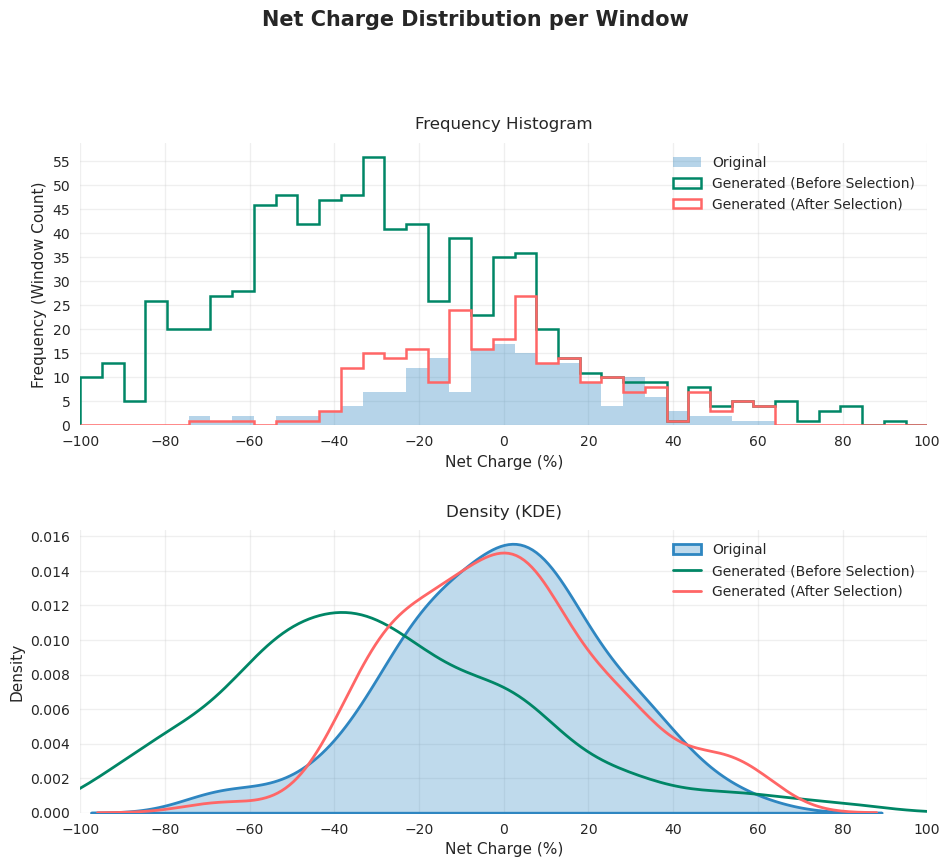


SELECTION SUMMARY
Selected 684 windows


In [30]:
import pandas as pd
import numpy as np
from typing import List, Tuple, Dict
import random

class SmartWindowSelector:
    """
    Intelligent window selection to maintain charge/discharge balance
    both globally and in batches
    """
    
    def __init__(self, windows: List[pd.DataFrame], 
                 batch_size: int = 120,
                 ratio_min: float = 0.98,
                 ratio_max: float = 1.02,
                 net_charge_range: Tuple[float, float] = (-70.5, 62.3)):
        """
        Initialize selector
        
        Parameters:
        windows: List of window DataFrames
        batch_size: Number of windows per batch (default: 120)
        ratio_min: Minimum acceptable charge/discharge ratio (default: 0.98)
        ratio_max: Maximum acceptable charge/discharge ratio (default: 1.02)
        net_charge_range: (min, max) acceptable net charge per window
        """
        self.windows = windows
        self.batch_size = batch_size
        self.ratio_min = ratio_min
        self.ratio_max = ratio_max
        self.net_charge_range = net_charge_range
        
        # Compute window statistics
        self.window_stats = []
        for i, w in enumerate(windows):
            net_charge = w['charge'].sum()
            charging = w[w['charge'] > 0]['charge'].sum()
            discharging = abs(w[w['charge'] < 0]['charge'].sum())
            
            self.window_stats.append({
                'index': i,
                'net_charge': net_charge,
                'charging': charging,
                'discharging': discharging,
                'ratio': charging / discharging if discharging > 0 else float('inf')
            })
        
        print(f"📊 Initialized SmartWindowSelector")
        print(f"   Total windows: {len(windows)}")
        print(f"   Batch size: {batch_size}")
        print(f"   Target ratio: [{ratio_min:.2f}, {ratio_max:.2f}]")
        print(f"   Net charge range: [{net_charge_range[0]:.1f}, {net_charge_range[1]:.1f}]")
    
    def filter_by_net_charge_range(self) -> List[int]:
        """Filter windows by net charge range"""
        valid_indices = []
        for stat in self.window_stats:
            if self.net_charge_range[0] <= stat['net_charge'] <= self.net_charge_range[1]:
                valid_indices.append(stat['index'])
        
        print(f"✅ Filtered by net charge range: {len(valid_indices)} windows remain")
        return valid_indices
    
    def compute_batch_ratio(self, window_indices: List[int]) -> float:
        """Compute charge/discharge ratio for a batch of windows"""
        total_charging = sum(self.window_stats[i]['charging'] for i in window_indices)
        total_discharging = sum(self.window_stats[i]['discharging'] for i in window_indices)
        
        if total_discharging == 0:
            return float('inf')
        return total_charging / total_discharging
    
    def optimization_based_selection(self, available_indices: List[int], 
                                    max_iterations: int = 5000) -> List[int]:
        """
        Optimization-based approach using simulated annealing
        to find better window ordering
        """
        print(f"\n🔧 Starting optimization-based selection...")
        
        n_complete_batches = len(available_indices) // self.batch_size
        
        # Start with a random permutation
        current_solution = available_indices.copy()
        random.shuffle(current_solution)
        current_score = self.evaluate_solution(current_solution, n_complete_batches)
        
        best_solution = current_solution.copy()
        best_score = current_score
        
        temperature = 100.0
        
        for iteration in range(max_iterations):
            # Generate neighbor by swapping two windows
            neighbor = current_solution.copy()
            i, j = random.sample(range(len(neighbor)), 2)
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            
            neighbor_score = self.evaluate_solution(neighbor, n_complete_batches)
            
            # Acceptance criterion
            if neighbor_score < current_score or random.random() < np.exp(-(neighbor_score - current_score) / temperature):
                current_solution = neighbor
                current_score = neighbor_score
                
                if current_score < best_score:
                    best_solution = current_solution.copy()
                    best_score = current_score
            
            # Cool down
            temperature *= 0.995
            
            if iteration % 500 == 0:
                print(f"      Iteration {iteration}: Best score = {best_score:.4f}")
        
        print(f"✅ Optimization complete. Best score: {best_score:.4f}")
        
        # Validate batches
        self.validate_solution(best_solution, n_complete_batches)
        
        return best_solution
    
    def evaluate_solution(self, solution: List[int], n_complete_batches: int) -> float:
        """
        Evaluate quality of a solution
        Lower score is better
        """
        score = 0.0
    
        for batch_num in range(max(0, n_complete_batches - 3)):
            batch_start = batch_num * self.batch_size
            batch_end = batch_start + self.batch_size
            batch_indices = solution[batch_start:batch_end]
    
            batch_ratio = self.compute_batch_ratio(batch_indices)
    
            # Penalty for being outside ratio range
            if batch_ratio < self.ratio_min:
                score += (self.ratio_min - batch_ratio) ** 2 * 1000
            elif batch_ratio > self.ratio_max:
                score += (batch_ratio - self.ratio_max) ** 2 * 1000
            else:
                # Small penalty for deviation from 1.0
                score += abs(batch_ratio - 1.0) * 10
    
        # Global ratio penalty (still applies)
        overall_ratio = self.compute_batch_ratio(solution)
        if overall_ratio < self.ratio_min:
            score += (self.ratio_min - overall_ratio) ** 2 * 500
        elif overall_ratio > self.ratio_max:
            score += (overall_ratio - self.ratio_max) ** 2 * 500
    
        return score
    
    
    def validate_solution(self, solution: List[int], n_complete_batches: int):
        """Print detailed validation of solution"""
        print(f"\n📋 Solution Validation:")
        print(f"   Total windows selected: {len(solution)}")
    
        all_valid = True
    
        for batch_num in range(n_complete_batches):
            batch_start = batch_num * self.batch_size
            batch_end = batch_start + self.batch_size
            batch_indices = solution[batch_start:batch_end]
    
            batch_ratio = self.compute_batch_ratio(batch_indices)
            in_range = self.ratio_min <= batch_ratio <= self.ratio_max
    
            # ✅ Mark last two batches as unconstrained
            unconstrained = batch_num >= n_complete_batches - 3
            if not in_range and not unconstrained:
                all_valid = False
    
            label = "(unconstrained)" if unconstrained else ("✓" if in_range else "✗ OUT OF RANGE")
            print(f"   Batch {batch_num + 1}: Ratio = {batch_ratio:.4f} {label}")
    
        # Handle last incomplete batch
        if len(solution) % self.batch_size != 0:
            last_batch_start = n_complete_batches * self.batch_size
            last_batch_indices = solution[last_batch_start:]
            last_ratio = self.compute_batch_ratio(last_batch_indices)
            print(f"   Last incomplete batch ({len(last_batch_indices)} windows): Ratio = {last_ratio:.4f} (not constrained)")
    
        # Global ratio summary
        overall_ratio = self.compute_batch_ratio(solution)
        overall_valid = self.ratio_min <= overall_ratio <= self.ratio_max
        print(f"\n   Overall ratio: {overall_ratio:.4f} {'✓' if overall_valid else '✗'}")
        print(f"   All constrained batches valid: {'YES ✅' if all_valid else 'NO ❌'}")

    
    '''def variability_preserving_selection(self, available_indices: List[int]) -> List[int]:
        """
        Variability-preserving algorithm that maintains the full range
        while balancing each batch
        
        Strategy:
        1. Categorize windows by net charge (extreme negative, moderate, extreme positive)
        2. Build each batch by mixing all categories to preserve variability
        3. Adjust proportions to hit target ratio
        """
        print(f"\n🎨 Starting variability-preserving selection...")
        
        # Step 1: Categorize windows by net charge
        windows_by_charge = []
        for idx in available_indices:
            net = self.window_stats[idx]['net_charge']
            charging = self.window_stats[idx]['charging']
            discharging = self.window_stats[idx]['discharging']
            windows_by_charge.append({
                'index': idx,
                'net_charge': net,
                'charging': charging,
                'discharging': discharging
            })
        
        # Sort by net charge
        windows_by_charge.sort(key=lambda x: x['net_charge'])
        
        # Identify extreme windows (preserve full range)
        n_windows = len(windows_by_charge)
        n_extreme = max(2, n_windows // 50)  # At least 2 or 2% on each extreme
        
        extreme_negative = windows_by_charge[:n_extreme]
        extreme_positive = windows_by_charge[-n_extreme:]
        middle_windows = windows_by_charge[n_extreme:-n_extreme]
        
        print(f"   Window categorization:")
        print(f"      Extreme negative: {len(extreme_negative)} windows (net: {extreme_negative[0]['net_charge']:.1f} to {extreme_negative[-1]['net_charge']:.1f})")
        print(f"      Middle range: {len(middle_windows)} windows")
        print(f"      Extreme positive: {len(extreme_positive)} windows (net: {extreme_positive[0]['net_charge']:.1f} to {extreme_positive[-1]['net_charge']:.1f})")
        
        # Step 2: Build batches by distributing all types
        selected_indices = []
        n_complete_batches = len(available_indices) // self.batch_size
        
        # Create pools
        neg_pool = extreme_negative.copy()
        mid_pool = middle_windows.copy()
        pos_pool = extreme_positive.copy()
        
        random.shuffle(neg_pool)
        random.shuffle(mid_pool)
        random.shuffle(pos_pool)
        
        for batch_num in range(n_complete_batches):
            print(f"\n   Building Batch {batch_num + 1}/{n_complete_batches}:")
            
            batch = []
            batch_charging = 0.0
            batch_discharging = 0.0
            
            # Target distribution per batch to preserve variability
            # Ensure each batch gets samples from all regions
            target_extreme_neg = max(3, len(extreme_negative) // (n_complete_batches + 1))
            target_extreme_pos = max(3, len(extreme_positive) // (n_complete_batches + 1))
            target_middle = self.batch_size - target_extreme_neg - target_extreme_pos
            
            # Phase 1: Add extreme negatives (preserve low range)
            added_neg = 0
            while added_neg < target_extreme_neg and neg_pool:
                w = neg_pool.pop(0)
                batch.append(w)
                batch_charging += w['charging']
                batch_discharging += w['discharging']
                added_neg += 1
            
            # Phase 2: Add extreme positives (preserve high range)
            added_pos = 0
            while added_pos < target_extreme_pos and pos_pool:
                w = pos_pool.pop(0)
                batch.append(w)
                batch_charging += w['charging']
                batch_discharging += w['discharging']
                added_pos += 1
            
            # Phase 3: Fill with middle windows, smartly choosing to balance ratio
            remaining_slots = self.batch_size - len(batch)
            
            for _ in range(remaining_slots):
                if not mid_pool:
                    break
                
                # Calculate current ratio
                current_ratio = batch_charging / batch_discharging if batch_discharging > 0 else float('inf')
                
                # Choose window that moves ratio toward target range
                best_window = None
                best_score = float('inf')
                
                # Look at next few candidates to make smart choice
                candidates = mid_pool[:min(20, len(mid_pool))]
                
                for w in candidates:
                    test_charging = batch_charging + w['charging']
                    test_discharging = batch_discharging + w['discharging']
                    test_ratio = test_charging / test_discharging if test_discharging > 0 else float('inf')
                    
                    # Score: how close to target ratio [0.98, 1.02]
                    if test_ratio < self.ratio_min:
                        score = (self.ratio_min - test_ratio) ** 2
                    elif test_ratio > self.ratio_max:
                        score = (test_ratio - self.ratio_max) ** 2
                    else:
                        score = abs(test_ratio - 1.0) * 0.1  # Small preference for 1.0
                    
                    if score < best_score:
                        best_score = score
                        best_window = w
                
                if best_window:
                    batch.append(best_window)
                    batch_charging += best_window['charging']
                    batch_discharging += best_window['discharging']
                    mid_pool.remove(best_window)
            
            # Calculate final batch ratio
            batch_ratio = batch_charging / batch_discharging if batch_discharging > 0 else float('inf')
            in_range = self.ratio_min <= batch_ratio <= self.ratio_max
            
            print(f"      Windows: {len(batch)} (extreme_neg: {added_neg}, middle: {len(batch)-added_neg-added_pos}, extreme_pos: {added_pos})")
            print(f"      Net charge range: [{min(w['net_charge'] for w in batch):.1f}, {max(w['net_charge'] for w in batch):.1f}]")
            print(f"      Ratio: {batch_ratio:.4f} {'✓' if in_range else '✗'}")
            
            # Extract indices
            selected_indices.extend([w['index'] for w in batch])
        
        # Add remaining windows (last incomplete batch)
        remaining_windows = neg_pool + mid_pool + pos_pool
        if remaining_windows:
            print(f"\n   Last incomplete batch: {len(remaining_windows)} windows")
            remaining_charging = sum(w['charging'] for w in remaining_windows)
            remaining_discharging = sum(w['discharging'] for w in remaining_windows)
            last_ratio = remaining_charging / remaining_discharging if remaining_discharging > 0 else float('inf')
            print(f"      Ratio: {last_ratio:.4f} (not constrained)")
            selected_indices.extend([w['index'] for w in remaining_windows])
        
        # Overall statistics
        overall_ratio = self.compute_batch_ratio(selected_indices)
        print(f"\n   ✅ Overall ratio: {overall_ratio:.4f}")
        
        # Show preserved range
        all_net_charges = [self.window_stats[i]['net_charge'] for i in selected_indices]
        print(f"   📊 Net charge range preserved: [{min(all_net_charges):.1f}, {max(all_net_charges):.1f}]")
        
        return selected_indices'''
    def variability_preserving_selection(self, available_indices: List[int]) -> List[int]:
        """
        Variability-preserving algorithm that maintains the full range
        while balancing each batch — with partial constraint control.
    
        🔧 Strategy:
        1. Categorize windows by net charge (extreme negative, middle, extreme positive)
        2. Compute global imbalance → used to bias selection
        3. Build each batch:
            - Constrained batches (first N-relaxation_term): optimize to reach ratio range
            - Unconstrained batches (last relaxation_term): variability only (absorb imbalance)
        4. Preserve full range of net charges across all selections
        """
    
        print(f"\n🎨 Starting variability-preserving selection...")
    
        # ----------------------------------------------------------------------
        # Step 1: Categorize windows by net charge
        # ----------------------------------------------------------------------
        windows_by_charge = []
        for idx in available_indices:
            net = self.window_stats[idx]['net_charge']
            charging = self.window_stats[idx]['charging']
            discharging = self.window_stats[idx]['discharging']
            windows_by_charge.append({
                'index': idx,
                'net_charge': net,
                'charging': charging,
                'discharging': discharging
            })
    
        # Sort windows by net charge
        windows_by_charge.sort(key=lambda x: x['net_charge'])
    
        n_windows = len(windows_by_charge)
        n_extreme = max(2, n_windows // 50)  # at least 2 or 2% of data per extreme
        n_extreme = 1
        extreme_negative = windows_by_charge[:n_extreme]
        extreme_positive = windows_by_charge[-n_extreme:]
        middle_windows = windows_by_charge[n_extreme:-n_extreme]
    
        print(f"   Window categorization:")
        print(f"      Extreme negative: {len(extreme_negative)} (range: {extreme_negative[0]['net_charge']:.2f} → {extreme_negative[-1]['net_charge']:.2f})")
        print(f"      Middle range:     {len(middle_windows)}")
        print(f"      Extreme positive: {len(extreme_positive)} (range: {extreme_positive[0]['net_charge']:.2f} → {extreme_positive[-1]['net_charge']:.2f})")
    
        # ----------------------------------------------------------------------
        # Step 2: Compute global imbalance → determines bias direction
        # ----------------------------------------------------------------------
        global_ratio = self.compute_batch_ratio(available_indices)
        print(f"\n🌐 Global ratio before selection: {global_ratio:.4f}")
    
        # If <1 → too much discharge (need to add more charging)
        # If >1 → too much charging (need to add more discharging)
        bias_direction = 1 if global_ratio < 1 else -1
        bias_strength = 0.05  # small factor influencing charge selection
    
        # ----------------------------------------------------------------------
        # Step 3: Build batches
        # ----------------------------------------------------------------------
        n_complete_batches = len(available_indices) // self.batch_size
        relaxation_term = 5
        n_constrained = max(0, n_complete_batches - relaxation_term)
    
        print(f"\n🧩 Total complete batches: {n_complete_batches}")
        print(f"   ➤ Constrained (optimized) batches: {n_constrained}")
        print(f"   ➤ Unconstrained (variability-only) batches: {n_complete_batches - n_constrained}")
    
        # Copy and shuffle category pools
        neg_pool = extreme_negative.copy()
        mid_pool = middle_windows.copy()
        pos_pool = extreme_positive.copy()
        random.shuffle(neg_pool)
        random.shuffle(mid_pool)
        random.shuffle(pos_pool)
    
        selected_indices = []
    
        for batch_num in range(n_complete_batches):
            is_constrained = batch_num < n_constrained
    
            print(f"\n   Building Batch {batch_num + 1}/{n_complete_batches}: {'⚙️ constrained (ratio optimized)' if is_constrained else '🎨 unconstrained (variability only)'}")
    
            batch = []
            batch_charging = 0.0
            batch_discharging = 0.0
    
            # Target contributions from each charge category
            target_extreme_neg = max(3, len(extreme_negative) // (n_complete_batches + 1))
            target_extreme_pos = max(3, len(extreme_positive) // (n_complete_batches + 1))
            target_middle = self.batch_size - target_extreme_neg - target_extreme_pos
    
            # --- Phase 1: Add extreme negatives
            added_neg = 0
            while added_neg < target_extreme_neg and neg_pool:
                w = neg_pool.pop(0)
                batch.append(w)
                batch_charging += w['charging']
                batch_discharging += w['discharging']
                added_neg += 1
    
            # --- Phase 2: Add extreme positives
            added_pos = 0
            while added_pos < target_extreme_pos and pos_pool:
                w = pos_pool.pop(0)
                batch.append(w)
                batch_charging += w['charging']
                batch_discharging += w['discharging']
                added_pos += 1
    
            # --- Phase 3: Fill middle windows (main optimization)
            remaining_slots = self.batch_size - len(batch)
    
            for _ in range(remaining_slots):
                if not mid_pool:
                    break
    
                if not is_constrained:
                    # 🎨 Unconstrained batches absorb global imbalance
                    # Bias toward same direction as imbalance
                    w = min(mid_pool[:50], key=lambda x: bias_direction * x['net_charge'])
                    mid_pool.remove(w)
                    batch.append(w)
                    batch_charging += w['charging']
                    batch_discharging += w['discharging']
                    continue
    
                # ⚙️ Constrained: actively optimize toward ratio range
                current_ratio = batch_charging / batch_discharging if batch_discharging > 0 else float('inf')
                best_window = None
                best_score = float('inf')
    
                candidates = mid_pool[:min(50, len(mid_pool))]  # small candidate pool for efficiency
    
                for w in candidates:
                    test_charging = batch_charging + w['charging']
                    test_discharging = batch_discharging + w['discharging']
                    test_ratio = test_charging / test_discharging if test_discharging > 0 else float('inf')
    
                    # Score for closeness to target ratio
                    if test_ratio < self.ratio_min:
                        score = (self.ratio_min - test_ratio) ** 2
                    elif test_ratio > self.ratio_max:
                        score = (test_ratio - self.ratio_max) ** 2
                    else:
                        score = abs(test_ratio - 1.0) * 0.1  # small preference for ratio ≈1
    
                    # Bias in *opposite* direction to correct global imbalance
                    score -= bias_direction * w['net_charge'] * bias_strength
    
                    if score < best_score:
                        best_score = score
                        best_window = w
    
                if best_window:
                    batch.append(best_window)
                    batch_charging += best_window['charging']
                    batch_discharging += best_window['discharging']
                    mid_pool.remove(best_window)
    
            # --- Compute and report final batch ratio
            batch_ratio = batch_charging / batch_discharging if batch_discharging > 0 else float('inf')
            in_range = self.ratio_min <= batch_ratio <= self.ratio_max
    
            print(f"      Windows: {len(batch)} (neg: {added_neg}, mid: {len(batch)-added_neg-added_pos}, pos: {added_pos})")
            print(f"      Net charge range: [{min(w['net_charge'] for w in batch):.2f}, {max(w['net_charge'] for w in batch):.2f}]")
            print(f"      Ratio: {batch_ratio:.4f} {'✓' if in_range else '✗'}")
    
            selected_indices.extend([w['index'] for w in batch])
    
        # ----------------------------------------------------------------------
        # Step 4: Handle last incomplete batch (if any)
        # ----------------------------------------------------------------------
        remaining_windows = neg_pool + mid_pool + pos_pool
        if remaining_windows:
            print(f"\n   Last incomplete batch: {len(remaining_windows)} windows (not constrained)")
            remaining_charging = sum(w['charging'] for w in remaining_windows)
            remaining_discharging = sum(w['discharging'] for w in remaining_windows)
            last_ratio = remaining_charging / remaining_discharging if remaining_discharging > 0 else float('inf')
            print(f"      Ratio: {last_ratio:.4f}")
            selected_indices.extend([w['index'] for w in remaining_windows])
    
        # ----------------------------------------------------------------------
        # Step 5: Summary statistics
        # ----------------------------------------------------------------------
        overall_ratio = self.compute_batch_ratio(selected_indices)
        all_net_charges = [self.window_stats[i]['net_charge'] for i in selected_indices]
        print(f"\n✅ Overall ratio: {overall_ratio:.4f}")
        print(f"📊 Net charge range preserved: [{min(all_net_charges):.2f}, {max(all_net_charges):.2f}]")
    
        return selected_indices





    
    def hybrid_optimization(self, available_indices: List[int], 
                          max_iterations: int = 3000) -> List[int]:
        """
        Hybrid approach: Start with variability-preserving, then optimize
        """
        print(f"\n🔧 Starting hybrid optimization...")
        
        # Start with variability-preserving solution
        initial_solution = self.variability_preserving_selection(available_indices)
        
        print(f"\n   Refining with local optimization...")
        
        n_complete_batches = len(available_indices) // self.batch_size
        current_solution = initial_solution.copy()
        current_score = self.evaluate_solution(current_solution, n_complete_batches)
        
        best_solution = current_solution.copy()
        best_score = current_score
        
        temperature = 50.0  # Lower temperature for fine-tuning
        improvements = 0
        
        for iteration in range(max_iterations):
            # Generate neighbor with local swaps (preserve some structure)
            neighbor = current_solution.copy()
            
            # Choose swap type
            if random.random() < 0.7:
                # Local swap within same or adjacent batches
                batch_idx = random.randint(0, n_complete_batches - 1)
                batch_start = batch_idx * self.batch_size
                batch_end = min(batch_start + self.batch_size * 2, len(neighbor))
                
                if batch_end - batch_start > 1:
                    i = random.randint(batch_start, batch_end - 1)
                    j = random.randint(batch_start, batch_end - 1)
                    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            else:
                # Global swap
                i, j = random.sample(range(len(neighbor)), 2)
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            
            neighbor_score = self.evaluate_solution(neighbor, n_complete_batches)
            
            # Acceptance criterion
            if neighbor_score < current_score or random.random() < np.exp(-(neighbor_score - current_score) / temperature):
                current_solution = neighbor
                current_score = neighbor_score
                
                if current_score < best_score:
                    best_solution = current_solution.copy()
                    best_score = current_score
                    improvements += 1
            
            # Cool down
            temperature *= 0.995
            
            if iteration % 500 == 0:
                print(f"      Iteration {iteration}: Best score = {best_score:.4f} ({improvements} improvements)")
        
        print(f"   ✅ Optimization complete: {improvements} improvements made")
        
        # Validate final solution
        self.validate_solution(best_solution, n_complete_batches)
        
        return best_solution
    
    
    def select_windows(self, method: str = 'optimization') -> List[pd.DataFrame]:
        """
        Main method to select windows
        
        Parameters:
        method: 'optimization', 'variability' or 'hybrid'
        
        Returns:
        List of selected windows in optimal order
        """
        print("="*80)
        print("SMART WINDOW SELECTION")
        print("="*80)
        
        # Step 1: Filter by net charge range
        valid_indices = self.filter_by_net_charge_range()
        
        if len(valid_indices) == 0:
            print("❌ No windows pass the net charge filter!")
            return [], []
        
        # Step 2: Select and order windows
        if method == 'optimization':
            selected_indices = self.optimization_based_selection(valid_indices)
        elif method == 'variability':
            selected_indices = self.variability_preserving_selection(valid_indices)
        elif method == 'hybrid':
            selected_indices = self.hybrid_optimization(valid_indices)
        else:
            raise ValueError(f"Unknown method: {method}. Choose: 'optimization', 'variability', 'hybrid'")
        
        # Step 3: Return selected windows
        selected_windows = [self.windows[i] for i in selected_indices]
        
        print(f"\n✅ Selection complete: {len(selected_windows)} windows selected")
        
        return selected_windows, selected_indices
    
    def export_selected_data(self, selected_windows: List[pd.DataFrame], 
                           output_path: str):
        """Export selected windows to CSV"""
        if not selected_windows:
            print("No windows to export!")
            return
        
        # Concatenate all selected windows
        selected_df = pd.concat(selected_windows, ignore_index=True)
        selected_df.to_csv(output_path, index=False)
        
        print(f"💾 Exported {len(selected_df)} rows to {output_path}")



import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

def plot_net_charge_distributions_full(df_original: pd.DataFrame,
                                       generated_df: pd.DataFrame,
                                       selected_windows: list[pd.DataFrame],
                                       seq_len: int = 10,
                                       N_win: int = 240):
    """
    Plot the distributions of net charges per window:
      1. Original data (seq_len-size windows)
      2. Generated data before selection (filtered between -100 and 100)
      3. Generated data after selection (first N_win windows)
    """

    # ---- Prepare original dataset windows ----
    df_original['charge'] = df_original['end_soc'] - df_original['soc'] 
    orig_windows = [
        df_original.iloc[i:i + seq_len]
        for i in range(0, len(df_original), seq_len)
        if len(df_original.iloc[i:i + seq_len]) == seq_len
    ]
    orig_net_charges = [w['charge'].sum() for w in orig_windows]

    # ---- Prepare generated (before selection) ----
    gen_windows = [
        generated_df.iloc[i:i + seq_len]
        for i in range(0, len(generated_df), seq_len)
        if len(generated_df.iloc[i:i + seq_len]) == seq_len
    ]
    gen_net_charges = [w['charge'].sum() for w in gen_windows]
    gen_net_charges = [x for x in gen_net_charges if -100 <= x <= 100]  # filter range

    # ---- Generated after selection (use first N_win windows) ----
    sel_net_charges = [w['charge'].sum() for w in selected_windows[:N_win]]

    # ---- Common settings ----
    datasets = {
        "Original": (orig_net_charges, "#2E86C1"),
        "Generated (Before Selection)": (gen_net_charges, "#008666"),
        "Generated (After Selection)": (sel_net_charges, "#FF6666")
    }

    bins = np.linspace(-100, 100, 40)
    sns.set_style("whitegrid")

    fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=False) 
    fig.suptitle("Net Charge Distribution per Window", fontsize=15, fontweight="bold")

    # Define xtick positions
    x_ticks = np.arange(-100, 120, 20)

    axes[0].yaxis.set_major_locator(MultipleLocator(5))

    # === 1️⃣ Frequency histogram (original filled, others outlined) ===
    axes[0].hist(datasets["Original"][0], bins=bins, color=datasets["Original"][1],
                 alpha=0.35, label="Original", edgecolor='none')
    for name in ["Generated (Before Selection)", "Generated (After Selection)"]:
        data, color = datasets[name]
        axes[0].hist(data, bins=bins, histtype='step',
                     color=color, linewidth=1.8, label=name)

    axes[0].set_xlabel("Net Charge (%)", fontsize=11)
    axes[0].set_ylabel("Frequency (Window Count)", fontsize=11)
    axes[0].set_title("Frequency Histogram", fontsize=12, pad=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(x_ticks)
    axes[0].yaxis.set_major_locator(MultipleLocator(5))
    axes[0].set_xlim(-100, 100)

    # === 2️⃣ Density (Original filled, others as unfilled KDEs) ===
    sns.kdeplot(datasets["Original"][0], ax=axes[1],
                color=datasets["Original"][1], fill=True,
                alpha=0.3, lw=2, label="Original")
    for name in ["Generated (Before Selection)", "Generated (After Selection)"]:
        data, color = datasets[name]
        sns.kdeplot(data, ax=axes[1],
                    color=color, lw=2, label=name, fill=False)

    axes[1].set_xlabel("Net Charge (%)", fontsize=11)
    axes[1].set_ylabel("Density", fontsize=11)
    axes[1].set_title("Density (KDE)", fontsize=12, pad=10)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(x_ticks)
    axes[1].set_xlim(-100, 100)

    plt.tight_layout(pad=2.5, h_pad=2.5, rect=[0, 0, 1, 0.96])
    plt.show()

    
# Integration with existing code
def apply_smart_selection_to_dataset(original_data_path: str, data_path: str, seq_len: int = 10,
                                    batch_size: int = 120,
                                    ratio_range: Tuple[float, float] = (0.98, 1.02),
                                    net_charge_range: Tuple[float, float] = (-70.5, 62.3),
                                    method: str = 'optimization',
                                    output_path: str = None):
    """
    Apply smart window selection to a dataset
    
    Parameters:
    data_path: Path to CSV file
    seq_len: Window size
    batch_size: Batch size for ratio constraints
    ratio_range: (min, max) acceptable charge/discharge ratio
    net_charge_range: (min, max) acceptable net charge per window
    method: 'optimization', 'variability' or 'hybrid'
    output_path: Path to save selected data (optional)
    """
    
    # Load data
    df = pd.read_csv(data_path)
    
    # Split into windows
    windows = [df.iloc[i:i+seq_len] for i in range(0, len(df), seq_len)]
    windows = [w for w in windows if len(w) == seq_len]  # Keep only complete windows
    
    print(f"📂 Loaded dataset: {len(windows)} complete windows")
    
    # Initialize selector
    selector = SmartWindowSelector(
        windows=windows,
        batch_size=batch_size,
        ratio_min=ratio_range[0],
        ratio_max=ratio_range[1],
        net_charge_range=net_charge_range
    )
    
    # Select windows
    selected_windows, selected_indices = selector.select_windows(method=method)
    
    # Export if path provided
    if output_path and selected_windows:
        selector.export_selected_data(selected_windows, output_path)

    df_original= pd.read_csv(original_data_path)
    
    plot_net_charge_distributions_full(
        df_original=df_original,                # original dataframe
        generated_df=df,               # generated dataset before selection
        selected_windows=selected_windows,
        seq_len=10,
        N_win=240
    )

    
    return selected_windows, selected_indices, selector


    
if __name__ == "__main__":
    
    # Example
    selected_windows, selected_indices, selector = apply_smart_selection_to_dataset(
        original_data_path='./datasets/new2_vehicle_2_47174e+18.csv',
        data_path='./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/valid_data_no_penalty.csv',
        seq_len=10,
        batch_size=120,
        ratio_range=(0.999, 1.001),
        net_charge_range=(-70.5, 62.3), #-70.5 and 62.3 are the bounds in the original dataset
        method='optimization',  # 'optimization', 'variability', 'hybrid'
        #output_path='./selected_windows_balanced.csv'
    )
    
    print("\n" + "="*80)
    print("SELECTION SUMMARY")
    print("="*80)
    print(f"Selected {len(selected_windows)} windows")

## Genetic Algorithm

In [ ]:
def algorithm_genetic(self, start_battery: float, 
                         population_size: int = 200,
                         generations: int = 1000,
                         mutation_rate: float = 0.15,
                         crossover_rate: float = 0.85,
                         elite_ratio: float = 0.1,
                         tournament_size: int = 7,
                         adaptive_params: bool = True) -> Optional[List[int]]:
        """
        Genetic Algorithm for EV Timeline Reconstruction with Different-Mode Charge Penalty
        """
        print("🧬 Running Genetic Algorithm...")
        
        def create_individual() -> List[int]:
            """Create a random individual with smart initialization strategies"""
            strategy = random.choice(['random', 'greedy_init', 'cluster_init', 'mode_aware_init'])
            
            if strategy == 'mode_aware_init':
                # Mode-aware initialization: avoid different-mode consecutive charges
                individual = []
                remaining = set(range(self.n_windows))
                current_battery = start_battery
                
                # Start with a random feasible window
                feasible_starts = []
                for w in remaining:
                    stats = self.window_stats[w]
                    if (current_battery + stats['min_intermediate_charge'] >= self.min_soc and 
                        current_battery + stats['max_intermediate_charge'] <= self.max_soc):
                        feasible_starts.append(w)
                
                if feasible_starts:
                    current = random.choice(feasible_starts)
                    individual.append(current)
                    remaining.remove(current)
                    current_battery += self.window_stats[current]['net_charge']
                
                # Greedily add remaining windows, avoiding different-mode violations
                while remaining:
                    best_candidates = []
                    last_end_mode = self.window_ends_with_charge_mode(individual[-1]) if individual else None
                    
                    for w in remaining:
                        stats = self.window_stats[w]
                        
                        # Check battery feasibility
                        if not (current_battery + stats['min_intermediate_charge'] >= self.min_soc and 
                                current_battery + stats['max_intermediate_charge'] <= self.max_soc):
                            continue
                        
                        # Check mode compatibility
                        start_mode = self.window_starts_with_charge_mode(w)
                        mode_violation = (last_end_mode is not None and 
                                        start_mode is not None and 
                                        last_end_mode != start_mode)  # DIFFERENT mode = violation
                        
                        end_battery = current_battery + stats['net_charge']
                        score = -abs(end_battery - 50)
                        
                        # Heavily favor non-violating windows
                        if not mode_violation:
                            score += 1000
                        
                        best_candidates.append((score, w))
                    
                    if best_candidates:
                        best_candidates.sort(reverse=True)
                        top_n = min(3, len(best_candidates))
                        current = best_candidates[random.randint(0, top_n-1)][1]
                    elif remaining:
                        current = random.choice(list(remaining))
                    else:
                        break
                    
                    individual.append(current)
                    remaining.remove(current)
                    current_battery += self.window_stats[current]['net_charge']
                
                return individual
            
            elif strategy == 'random':
                individual = list(range(self.n_windows))
                random.shuffle(individual)
                return individual
            
            elif strategy == 'greedy_init':
                individual = []
                remaining = set(range(self.n_windows))
                current_battery = start_battery
                
                feasible_starts = []
                for w in remaining:
                    stats = self.window_stats[w]
                    if (current_battery + stats['min_intermediate_charge'] >= self.min_soc and 
                        current_battery + stats['max_intermediate_charge'] <= self.max_soc):
                        feasible_starts.append(w)
                
                if feasible_starts:
                    current = random.choice(feasible_starts)
                    individual.append(current)
                    remaining.remove(current)
                    current_battery += self.window_stats[current]['net_charge']
                
                while remaining:
                    best_candidates = []
                    for w in remaining:
                        stats = self.window_stats[w]
                        if (current_battery + stats['min_intermediate_charge'] >= self.min_soc and 
                            current_battery + stats['max_intermediate_charge'] <= self.max_soc):
                            end_battery = current_battery + stats['net_charge']
                            score = -abs(end_battery - 50)
                            best_candidates.append((score, w))
                    
                    if best_candidates:
                        best_candidates.sort(reverse=True)
                        top_n = min(3, len(best_candidates))
                        current = best_candidates[random.randint(0, top_n-1)][1]
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                    else:
                        current = random.choice(list(remaining))
                        individual.append(current)
                        remaining.remove(current)
                        current_battery += self.window_stats[current]['net_charge']
                
                return individual
            
            else:  # cluster_init
                individual = list(range(self.n_windows))
                positive_windows = [i for i in individual if self.window_stats[i]['net_charge'] > 0]
                negative_windows = [i for i in individual if self.window_stats[i]['net_charge'] < 0]
                neutral_windows = [i for i in individual if self.window_stats[i]['net_charge'] == 0]
                
                random.shuffle(positive_windows)
                random.shuffle(negative_windows)
                random.shuffle(neutral_windows)
                
                result = []
                max_len = max(len(positive_windows), len(negative_windows), len(neutral_windows))
                for i in range(max_len):
                    if i < len(positive_windows):
                        result.append(positive_windows[i])
                    if i < len(negative_windows):
                        result.append(negative_windows[i])
                    if i < len(neutral_windows):
                        result.append(neutral_windows[i])
                
                return result
        
        def fitness(individual: List[int]) -> float:
            """Advanced fitness function - INCLUDES DIFFERENT-MODE CHARGE PENALTY"""
            battery = start_battery
            penalty = 0
            battery_trace = [battery]
            
            for i, window_id in enumerate(individual):
                stats = self.window_stats[window_id]
                
                # 🚫 CHECK FOR CONSECUTIVE DIFFERENT-MODE CHARGE VIOLATIONS
                if i > 0:
                    prev_id = individual[i - 1]
                    end_mode = self.window_ends_with_charge_mode(prev_id)
                    start_mode = self.window_starts_with_charge_mode(window_id)
                    if end_mode is not None and start_mode is not None and end_mode != start_mode:
                        penalty += self.different_mode_penalty
                
                # Check intermediate constraints
                min_battery = battery + stats['min_intermediate_charge']
                max_battery = battery + stats['max_intermediate_charge']
                
                if min_battery < self.min_soc:
                    penalty += (self.min_soc - min_battery) * 2000
                if max_battery > self.max_soc:
                    penalty += (max_battery - self.max_soc) * 2000
                
                battery += stats['net_charge']
                battery_trace.append(battery)
                
                if battery < self.min_soc:
                    penalty += abs(battery) * 1500
                if battery > self.max_soc:
                    penalty += (battery - self.max_soc) * 1500
            
            battery_variance = np.var(battery_trace)
            mean_distance_from_optimal = np.mean([abs(b - 50) for b in battery_trace])
            
            penalty += battery_variance * 0.5
            penalty += mean_distance_from_optimal * 2
            
            final_battery = battery_trace[-1]
            if 20 <= final_battery <= 80:
                penalty -= 50
            
            max_swing = max(battery_trace) - min(battery_trace)
            if max_swing < 60:
                penalty -= 20
            
            return -penalty
        
        def tournament_selection(population: List[List[int]], k: int = None) -> List[int]:
            if k is None:
                k = tournament_size
            tournament = random.sample(population, min(k, len(population)))
            return max(tournament, key=fitness)
        
        def rank_selection(population: List[List[int]]) -> List[int]:
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            ranks = list(range(len(population_with_fitness), 0, -1))
            total_rank = sum(ranks)
            
            pick = random.uniform(0, total_rank)
            current = 0
            for i, rank in enumerate(ranks):
                current += rank
                if current >= pick:
                    return population_with_fitness[i][0]
            
            return population_with_fitness[0][0]
        
        def order_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = [None] * n
            child2 = [None] * n
            
            child1[start:end] = parent1[start:end]
            child2[start:end] = parent2[start:end]
            
            def fill_child(child, other_parent):
                remaining = [x for x in other_parent if x not in child]
                remaining_iter = iter(remaining)
                for i in range(n):
                    if child[i] is None:
                        child[i] = next(remaining_iter)
            
            fill_child(child1, parent2)
            fill_child(child2, parent1)
            
            return child1, child2
        
        def pmx_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            n = len(parent1)
            start, end = sorted(random.sample(range(n), 2))
            
            child1 = parent1.copy()
            child2 = parent2.copy()
            
            mapping1 = {}
            mapping2 = {}
            
            for i in range(start, end):
                val1, val2 = child1[i], child2[i]
                child1[i], child2[i] = val2, val1
                mapping1[val2] = val1
                mapping2[val1] = val2
            
            def fix_conflicts(child, mapping):
                for i in list(range(0, start)) + list(range(end, n)):
                    while child[i] in mapping:
                        child[i] = mapping[child[i]]
            
            fix_conflicts(child1, mapping1)
            fix_conflicts(child2, mapping2)
            
            return child1, child2
        
        def cycle_crossover(parent1: List[int], parent2: List[int]) -> Tuple[List[int], List[int]]:
            n = len(parent1)
            child1 = [None] * n
            child2 = [None] * n
            
            visited = [False] * n
            
            for start in range(n):
                if visited[start]:
                    continue
                
                use_parent1 = (sum(visited) // n) % 2 == 0
                
                current = start
                while not visited[current]:
                    visited[current] = True
                    if use_parent1:
                        child1[current] = parent1[current]
                        child2[current] = parent2[current]
                    else:
                        child1[current] = parent2[current]
                        child2[current] = parent1[current]
                    
                    target_val = parent2[current] if use_parent1 else parent1[current]
                    current = parent1.index(target_val)
            
            return child1, child2
        
        def mutate(individual: List[int], rate: float) -> List[int]:
            """Advanced mutation with multiple operators"""
            if random.random() > rate:
                return individual
            
            mutated = individual.copy()
            mutation_type = random.choice(['swap', 'insert', 'inversion', 'scramble', 'mode_aware_swap'])
            
            if mutation_type == 'mode_aware_swap':
                # Mode-aware swap: try to fix different-mode violations
                has_violation, _ = self.check_consecutive_different_mode_violation(mutated)
                if has_violation:
                    violation_positions = []
                    for i in range(len(mutated) - 1):
                        end_mode = self.window_ends_with_charge_mode(mutated[i])
                        start_mode = self.window_starts_with_charge_mode(mutated[i + 1])
                        if end_mode is not None and start_mode is not None and end_mode != start_mode:
                            violation_positions.append(i)
                    
                    if violation_positions:
                        violation_pos = random.choice(violation_positions)
                        other_pos = random.choice([p for p in range(len(mutated)) if p not in [violation_pos, violation_pos + 1]])
                        mutated[violation_pos + 1], mutated[other_pos] = mutated[other_pos], mutated[violation_pos + 1]
                else:
                    i, j = random.sample(range(len(mutated)), 2)
                    mutated[i], mutated[j] = mutated[j], mutated[i]
            
            elif mutation_type == 'swap':
                i, j = random.sample(range(len(mutated)), 2)
                mutated[i], mutated[j] = mutated[j], mutated[i]
            
            elif mutation_type == 'insert':
                i = random.randint(0, len(mutated) - 1)
                element = mutated.pop(i)
                j = random.randint(0, len(mutated))
                mutated.insert(j, element)
            
            elif mutation_type == 'inversion':
                i, j = sorted(random.sample(range(len(mutated)), 2))
                mutated[i:j+1] = reversed(mutated[i:j+1])
            
            elif mutation_type == 'scramble':
                i, j = sorted(random.sample(range(len(mutated)), 2))
                segment = mutated[i:j+1]
                random.shuffle(segment)
                mutated[i:j+1] = segment
            
            return mutated
        
        def local_search(individual: List[int], max_improvements: int = 5) -> List[int]:
            """Local search to improve solution"""
            current = individual.copy()
            current_fitness = fitness(current)
            improvements = 0
            
            for _ in range(20):
                if improvements >= max_improvements:
                    break
                
                best_neighbor = None
                best_fitness = current_fitness
                
                for i in range(len(current)):
                    for j in range(i + 1, len(current)):
                        neighbor = current.copy()
                        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                        
                        neighbor_fitness = fitness(neighbor)
                        if neighbor_fitness > best_fitness:
                            best_neighbor = neighbor
                            best_fitness = neighbor_fitness
                
                if best_neighbor is not None:
                    current = best_neighbor
                    current_fitness = best_fitness
                    improvements += 1
                else:
                    break
            
            return current
        
        # Initialize population
        population = [create_individual() for _ in range(population_size)]
        
        best_individual = None
        best_fitness = float('-inf')
        stagnation_counter = 0
        fitness_history = []
        
        current_mutation_rate = mutation_rate
        current_tournament_size = tournament_size
        
        for generation in range(generations):
            population_with_fitness = [(ind, fitness(ind)) for ind in population]
            population_with_fitness.sort(key=lambda x: x[1], reverse=True)
            
            current_best_fitness = population_with_fitness[0][1]
            fitness_history.append(current_best_fitness)
            
            if current_best_fitness > best_fitness:
                best_individual = population_with_fitness[0][0].copy()
                best_fitness = current_best_fitness
                stagnation_counter = 0
            else:
                stagnation_counter += 1
            
            if adaptive_params:
                if stagnation_counter > 20:
                    current_mutation_rate = min(0.3, current_mutation_rate * 1.1)
                    current_tournament_size = max(3, current_tournament_size - 1)
                elif stagnation_counter < 5:
                    current_mutation_rate = max(0.05, current_mutation_rate * 0.95)
                    current_tournament_size = min(10, current_tournament_size + 1)
            
            if stagnation_counter > 100:
                print(f"  Early stopping at generation {generation}")
                break
            
            if generation % 50 == 0:
                avg_fitness = np.mean([f for _, f in population_with_fitness])
                print(f"  Generation {generation}: Best = {best_fitness:.2f}, Avg = {avg_fitness:.2f}, "
                      f"Mutation = {current_mutation_rate:.3f}")
            
            new_population = []
            elite_size = int(population_size * elite_ratio)
            
            elite_individuals = [ind for ind, _ in population_with_fitness[:elite_size]]
            new_population.extend(elite_individuals)
            
            if generation % 10 == 0:
                for i in range(min(3, len(elite_individuals))):
                    elite_individuals[i] = local_search(elite_individuals[i])
            
            while len(new_population) < population_size:
                if random.random() < crossover_rate:
                    if random.random() < 0.7:
                        parent1 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                        parent2 = tournament_selection([ind for ind, _ in population_with_fitness], 
                                                     current_tournament_size)
                    else:
                        parent1 = rank_selection([ind for ind, _ in population_with_fitness])
                        parent2 = rank_selection([ind for ind, _ in population_with_fitness])
                    
                    crossover_op = random.choice([order_crossover, pmx_crossover, cycle_crossover])
                    child1, child2 = crossover_op(parent1, parent2)
                    
                    child1 = mutate(child1, current_mutation_rate)
                    child2 = mutate(child2, current_mutation_rate)
                    
                    new_population.append(child1)
                    if len(new_population) < population_size:
                        new_population.append(child2)
                else:
                    parent = tournament_selection([ind for ind, _ in population_with_fitness])
                    child = mutate(parent, current_mutation_rate * 2)
                    new_population.append(child)
            
            population = new_population[:population_size]
        
        print(f"  Final best fitness: {best_fitness:.2f}")
        
        if best_individual:
            has_violation, num_violations = self.check_consecutive_different_mode_violation(best_individual)
            if has_violation:
                print(f"  ⚠️  Warning: Best solution has {num_violations} different-mode violations")
            else:
                print(f"  ✅ Best solution has NO different-mode violations")
        
        return best_individual if best_fitness > float('-inf') else None
    